# Comparison Plots 
## M1 vs. M2 vs. M3

In [13]:
# --- Parameters & Setup ---
PROJECT_ROOT <- sub("[/\\\\][^/\\\\]*$", "", getwd())
print(PROJECT_ROOT)

data_dir <- file.path(PROJECT_ROOT, 'data')
models_dir <- file.path(PROJECT_ROOT, 'models')
reports_dir <- file.path(PROJECT_ROOT, 'reports')
augmented_dir <- file.path(data_dir, 'augmented')
augmented_reports_dir <- file.path(reports_dir, 'xfg_success_augmented')
ipw_reports_dir <- file.path(reports_dir, 'xfg_success_ipw')

# --- Library Imports ---
dependencies <- c(
  'dplyr', 'tibble', 'tidyr', 'readr', 'stringr', 'purrr', 'ggplot2','broom.mixed',
  'splines', 'splines2', 'glmmTMB', 'pROC', 'rlang', 'scales', 'minqa','lme4','patchwork','ggrepel'
)
installed <- rownames(installed.packages())
for (pkg in dependencies) {
  if (!pkg %in% installed) install.packages(pkg)
  suppressPackageStartupMessages(library(pkg, character.only = TRUE))
}

# Set plot theme
theme_set(theme_minimal())
print("Libraries loaded.")

[1] "g:/Other computers/Desktop/My Files/Python/Sports Analytics Projects/Football/Kickers/NFL-Field-Goal-Kicker-Model"


[1] "Libraries loaded."


In [36]:
# ==============================================================================
# 0. Load Libraries & Define Utility Functions
# ==============================================================================
# --- USER PROVIDED UTILITY FUNCTIONS ---

# Distance B-splines using splines2
build_distance_bs <- function(x, knots, bknots, degree = 3, intercept = FALSE) {
  stopifnot(!missing(x), !missing(knots), !missing(bknots))
  if (!requireNamespace("splines2", quietly = TRUE)) stop("Package 'splines2' required")
  bs <- splines2::bSpline(x, knots = knots, Boundary.knots = bknots, degree = degree, intercept = intercept)
  bs <- as.data.frame(bs)
  names(bs) <- paste0("dist_bs_", seq_len(ncol(bs)))
  bs
}

# Loss metrics
brier <- function(y, p) mean((y - p)^2, na.rm = TRUE)
logloss <- function(y, p, eps = 1e-15) -mean(y * log(pmin(pmax(p, eps), 1 - eps)) + (1 - y) * log(1 - pmin(pmax(p, eps), 1 - eps)), na.rm = TRUE)
auc <- function(y, p) {
  keep <- is.finite(p) & is.finite(y)
  if (sum(keep) < 2 || length(unique(y[keep])) < 2) return(NA_real_)
  as.numeric(pROC::auc(y[keep], p[keep], quiet = TRUE))
}

# Safe prediction helper with diagnostics
predict_safe <- function(fit, newdata) {
  if (is.null(fit)) return(rep(NA_real_, nrow(newdata)))
  p_resp <- tryCatch(as.numeric(stats::predict(fit, newdata = newdata, type = "response", allow.new.levels = TRUE)), error = function(e) {
    cat("ERROR in stats::predict:\n")
    cat("Message:", conditionMessage(e), "\n")
    cat("Call:", deparse(conditionCall(e)), "\n")
    NULL
  })
  if (!is.null(p_resp)) return(pmin(pmax(p_resp, 0), 1))
  rep(NA_real_, nrow(newdata))
}

# Pool sparse random effect levels
pool_sparse_levels <- function(train_df, test_df, id_col, min_n = 5L, repl = "REPL", keep_cols = NULL) {
  stopifnot(id_col %in% names(train_df), id_col %in% names(test_df))
  if (!is.null(keep_cols)) {
    train_df <- train_df %>% dplyr::select(dplyr::any_of(keep_cols))
    test_df  <- test_df  %>% dplyr::select(dplyr::any_of(keep_cols))
  }
  tab <- table(train_df[[id_col]])
  keep_levels <- names(tab)[tab >= min_n]
  train_df[[id_col]] <- ifelse(train_df[[id_col]] %in% keep_levels, as.character(train_df[[id_col]]), repl)
  test_df[[id_col]]  <- ifelse(test_df[[id_col]] %in% keep_levels, as.character(test_df[[id_col]]), repl)
  all_levels <- unique(c(train_df[[id_col]], test_df[[id_col]]))
  train_df[[id_col]] <- factor(train_df[[id_col]], levels = all_levels)
  test_df[[id_col]]  <- factor(test_df[[id_col]], levels = all_levels)
  list(train = train_df, test = test_df)
}

# --- 1. Redefine Metric Helper Function (Ensures latest version is active) ---
calc_metrics <- function(y, p, set_name, threshold = 0.5) {
  # specific requires
  requireNamespace("Metrics", quietly = TRUE)
  requireNamespace("pROC", quietly = TRUE)
  
  # Filter for validity
  valid <- is.finite(p) & is.finite(y)
  y <- y[valid]
  p <- p[valid]
  
  # --- Probabilistic Metrics ---
  val_brier <- mean((y - p)^2)
  val_ll    <- Metrics::logLoss(y, p)
  
  # AUC (Safe calculation)
  val_auc <- if (length(unique(y)) < 2) NA_real_ else as.numeric(pROC::auc(y, p, quiet = TRUE))
  
  # Calibration Error (L1)
  cal_df <- tibble::tibble(y = y, p = p) %>%
    dplyr::mutate(bin = dplyr::ntile(p, 10)) %>%
    dplyr::group_by(bin) %>%
    dplyr::summarise(mean_pred = mean(p), mean_obs = mean(y), .groups="drop") %>%
    dplyr::mutate(diff = abs(mean_pred - mean_obs))
  val_calib <- mean(cal_df$diff, na.rm=TRUE)
  
  # --- Classification Metrics (at threshold) ---
  pred_class <- ifelse(p >= threshold, 1, 0)
  
  TP <- sum(y == 1 & pred_class == 1)
  TN <- sum(y == 0 & pred_class == 0)
  FP <- sum(y == 0 & pred_class == 1)
  FN <- sum(y == 1 & pred_class == 0)
  
  val_acc <- (TP + TN) / length(y)
  
  # Handle division by zero for Precision/Recall
  val_prec <- if ((TP + FP) > 0) TP / (TP + FP) else 0.0
  val_rec  <- if ((TP + FN) > 0) TP / (TP + FN) else 0.0
  val_f1   <- if ((val_prec + val_rec) > 0) 2 * (val_prec * val_rec) / (val_prec + val_rec) else 0.0
  
  # Return structured tibble
  tibble::tibble(
    set = set_name,
    brier = val_brier,
    logloss = val_ll,
    auc = val_auc,
    calib_error = val_calib,
    accuracy = val_acc,
    precision = val_prec,
    recall = val_rec,
    f1_score = val_f1
  )
}

# --- 2. Define Control Settings ---
ctrl <- glmmTMB::glmmTMBControl(
  optimizer = nlminb, 
  optCtrl = list(iter.max = 1000, eval.max = 1000),
  parallel = 6
)

In [14]:
# Load necessary libraries
library(readr)
library(dplyr)

# Load the prediction datasets
# Assuming ipw_reports_dir and augmented_reports_dir are already defined
pred_ipw <- read_csv(file.path(ipw_reports_dir, 'fg_full_with_ipw_predictions.csv'), show_col_types = FALSE)
aug_pred <- read_csv(file.path(augmented_reports_dir, 'fg_full_with_augmented_predictions.csv'), show_col_types = FALSE)

# Select only the key columns and the desired prediction from the augmented data
aug_m3_pred <- aug_pred %>%
  select(game_id, play_id, pred_m3_full)

# Join the 'pred_m3_full' column to the main IPW dataset by game_id and play_id
# The result is the final pooled dataset for downstream use.
fg_full_pooled <- pred_ipw %>%
  left_join(aug_m3_pred, by = c("game_id", "play_id"))

# Preview the first few rows and the names of the last few columns to verify the merge
print("Preview of the final pooled dataset:")
print(head(fg_full_pooled))

print("Last few column names to confirm 'pred_m3_full' is added:")
print(tail(names(fg_full_pooled), 4))


[1] "Preview of the final pooled dataset:"
# A tibble: 6 × 110
  game_id play_id old_game_id season  week season_type playoffs   qtr game_date 
  <chr>     <dbl>       <dbl>  <dbl> <dbl> <chr>          <dbl> <dbl> <date>    
1 2015_0…     580  2015091309   2015     1 REG                0     1 2015-09-13
2 2015_0…     824  2015091309   2015     1 REG                0     1 2015-09-13
3 2015_0…    1357  2015091309   2015     1 REG                0     2 2015-09-13
4 2015_0…    1823  2015091309   2015     1 REG                0     2 2015-09-13
5 2015_0…    2282  2015091309   2015     1 REG                0     3 2015-09-13
6 2015_0…    3449  2015091309   2015     1 REG                0     4 2015-09-13
# ℹ 101 more variables: home_team <chr>, away_team <chr>, posteam <chr>,
#   defteam <chr>, game_seconds_remaining <dbl>,
#   quarter_seconds_remaining <dbl>, score_differential <dbl>,
#   yardline_100 <dbl>, ydstogo <dbl>, wp <dbl>, home_wp <dbl>, epa <dbl>,
#   posteam_timeouts_remainin

In [15]:
#Show rows with missing values in 'pred_m3_full'
print("Rows with missing values in 'pred_m3_full':")
#select only game_id, kick_distance, and pred_m3_full for clarity
print(fg_full_pooled %>% filter(is.na(pred_m3_full)) %>% select(game_id, kick_distance, pred_m3_full))

[1] "Rows with missing values in 'pred_m3_full':"


# A tibble: 0 × 3
# ℹ 3 variables: game_id <chr>, kick_distance <dbl>, pred_m3_full <dbl>


In [47]:
#show colnames in the final pooled dataset
print("Column names in the final pooled dataset:")
print(names(fg_full_pooled))

[1] "Column names in the final pooled dataset:"
  [1] "game_id"                    "play_id"                   
  [3] "old_game_id"                "season"                    
  [5] "week"                       "season_type"               
  [7] "playoffs"                   "qtr"                       
  [9] "game_date"                  "home_team"                 
 [11] "away_team"                  "posteam"                   
 [13] "defteam"                    "game_seconds_remaining"    
 [15] "quarter_seconds_remaining"  "score_differential"        
 [17] "yardline_100"               "ydstogo"                   
 [19] "wp"                         "home_wp"                   
 [21] "epa"                        "posteam_timeouts_remaining"
 [23] "defteam_timeouts_remaining" "goal_to_go"                
 [25] "is_ot"                      "roof"                      
 [27] "surface"                    "temp"                      
 [29] "wind"                       "weather"            

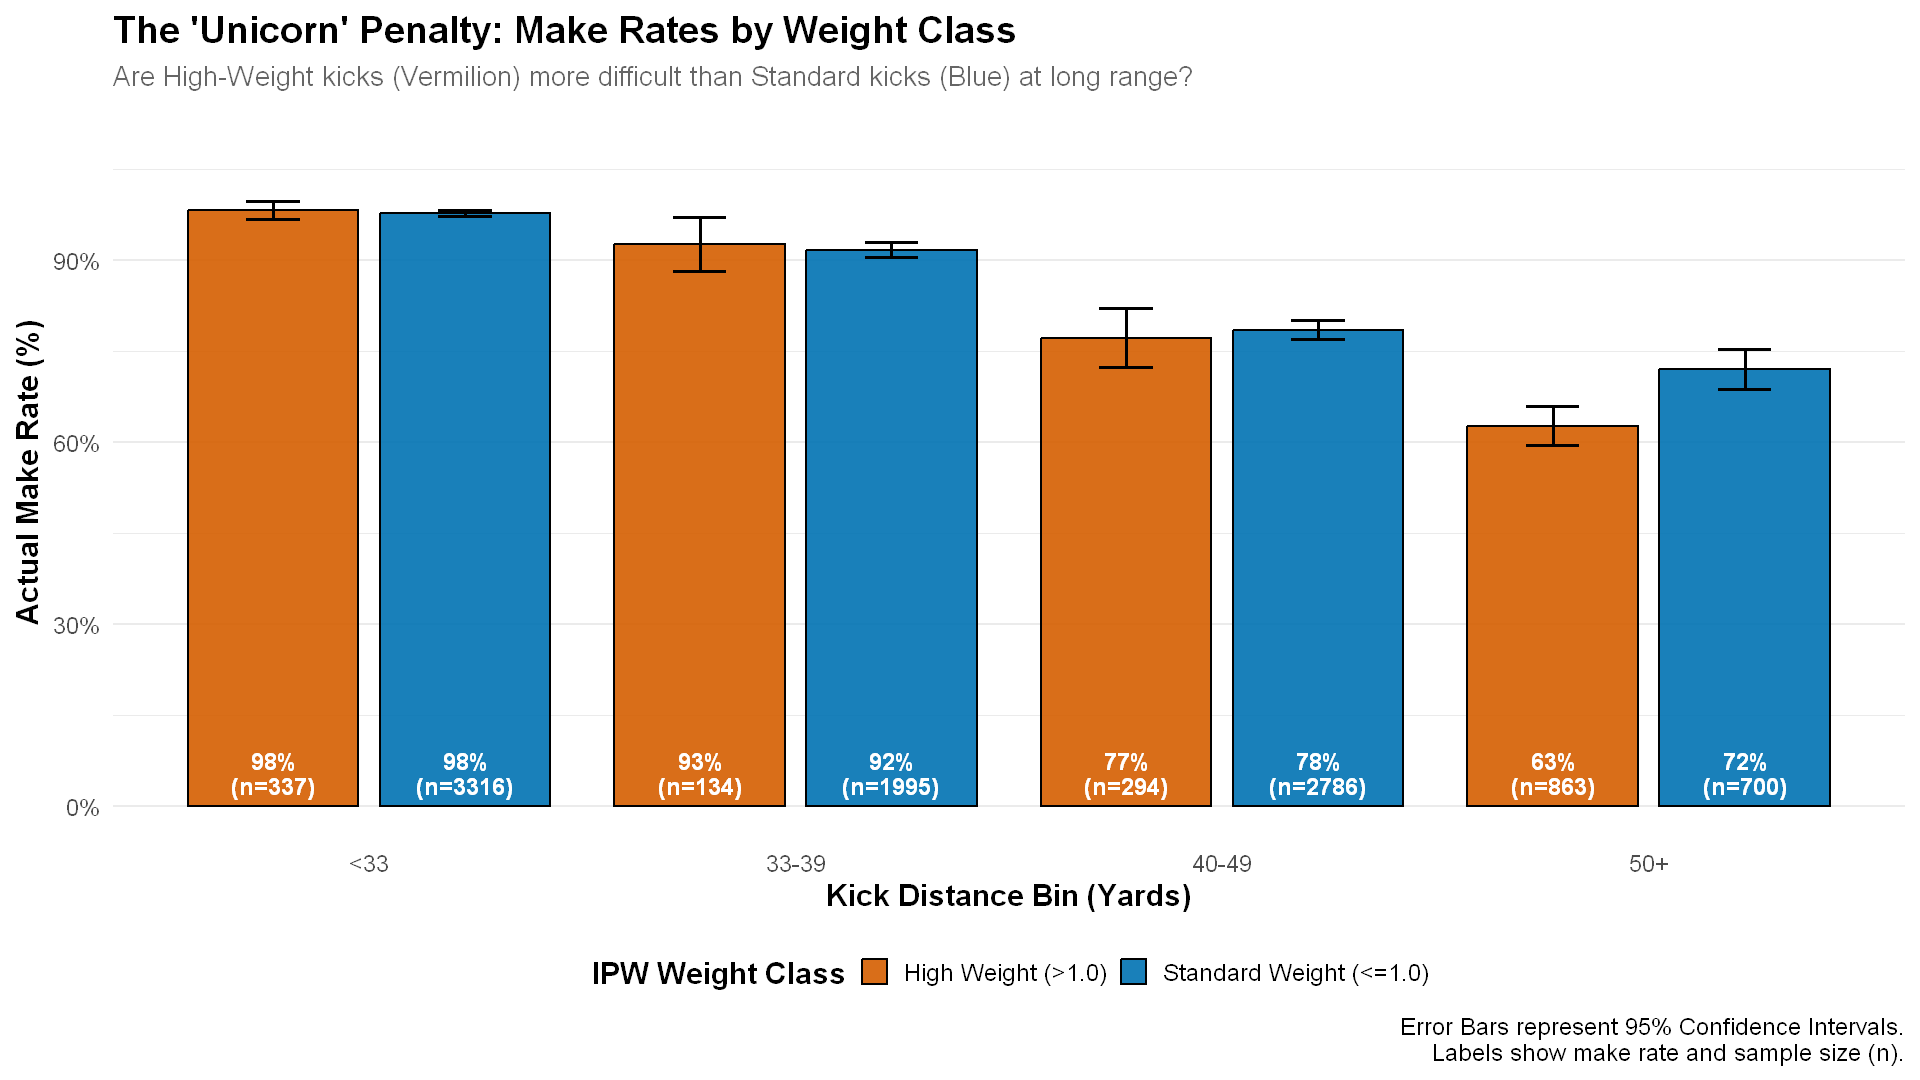

In [88]:
library(tidyverse)

# ==============================================================================
# Weight Analysis: Performance by Propensity Category (With Counts)
# ==============================================================================

# 1. Prepare Data & Calculate Statistics
weight_analysis <- fg_full_pooled %>%
  dplyr::filter(kick_distance <= 65) %>%
  dplyr::mutate(
    distance_bin = cut(kick_distance, 
                       breaks = c(0, 33, 40, 50, 65), 
                       labels = c("<33", "33-39", "40-49", "50+"),
                       right = TRUE),
    Weight_Category = ifelse(weight_multinom_hajek > 1, "High Weight (>1.0)", "Standard Weight (<=1.0)")
  ) %>%
  dplyr::group_by(distance_bin, Weight_Category) %>%
  dplyr::summarise(
    n = dplyr::n(),
    make_rate = mean(kick_made, na.rm = TRUE),
    se = sqrt((make_rate * (1 - make_rate)) / n),
    lower = pmax(0, make_rate - 1.96 * se),
    upper = pmin(1, make_rate + 1.96 * se),
    .groups = "drop"
  )

# 2. Visualization
weight_cols <- c("Standard Weight (<=1.0)" = "#0072B2", "High Weight (>1.0)" = "#D55E00")

p_weight_perf <- ggplot(weight_analysis, aes(x = distance_bin, y = make_rate, fill = Weight_Category)) +
  
  # Bars
  geom_bar(stat = "identity", position = position_dodge(width = 0.9), width = 0.8, color = "black", alpha = 0.9) +
  
  # Error Bars
  geom_errorbar(aes(ymin = lower, ymax = upper), 
                position = position_dodge(width = 0.9), width = 0.25, size = 1, color = "black") +
  
  # --- CHANGED: Labels with Counts ---
  # Paste percentage and count together with a line break (\n)
  geom_text(aes(label = paste0(scales::percent(make_rate, accuracy = 1), "\n(n=", n, ")"), 
                y = 0.02), # Base position
            position = position_dodge(width = 0.9), 
            vjust = 0,       # Bottom-up alignment
            color = "white", 
            size = 5,        # Adjusted size slightly for fit
            fontface = "bold",
            lineheight = 0.9) + # Tighter line spacing
  
  # Formatting
  scale_fill_manual(values = weight_cols) +
  scale_y_continuous(labels = scales::percent, limits = c(0, 1.1)) + 
  
  labs(
    title = "The 'Unicorn' Penalty: Make Rates by Weight Class",
    subtitle = "Are High-Weight kicks (Vermilion) more difficult than Standard kicks (Blue) at long range?",
    x = "Kick Distance Bin (Yards)",
    y = "Actual Make Rate (%)",
    fill = "IPW Weight Class",
    caption = "Error Bars represent 95% Confidence Intervals.\nLabels show make rate and sample size (n)."
  ) +
  
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(face = "bold", size = 22),
    plot.subtitle = element_text(size = 16, color = "grey40"),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    panel.grid.major.x = element_blank()
  )

# Display
options(repr.plot.width = 16, repr.plot.height = 9)
print(p_weight_perf)

# Save
if(exists("reports_dir")) {
  ggsave(file.path(reports_dir, "weight_impact_make_rate_with_counts.png"), p_weight_perf, width = 16, height = 9)
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


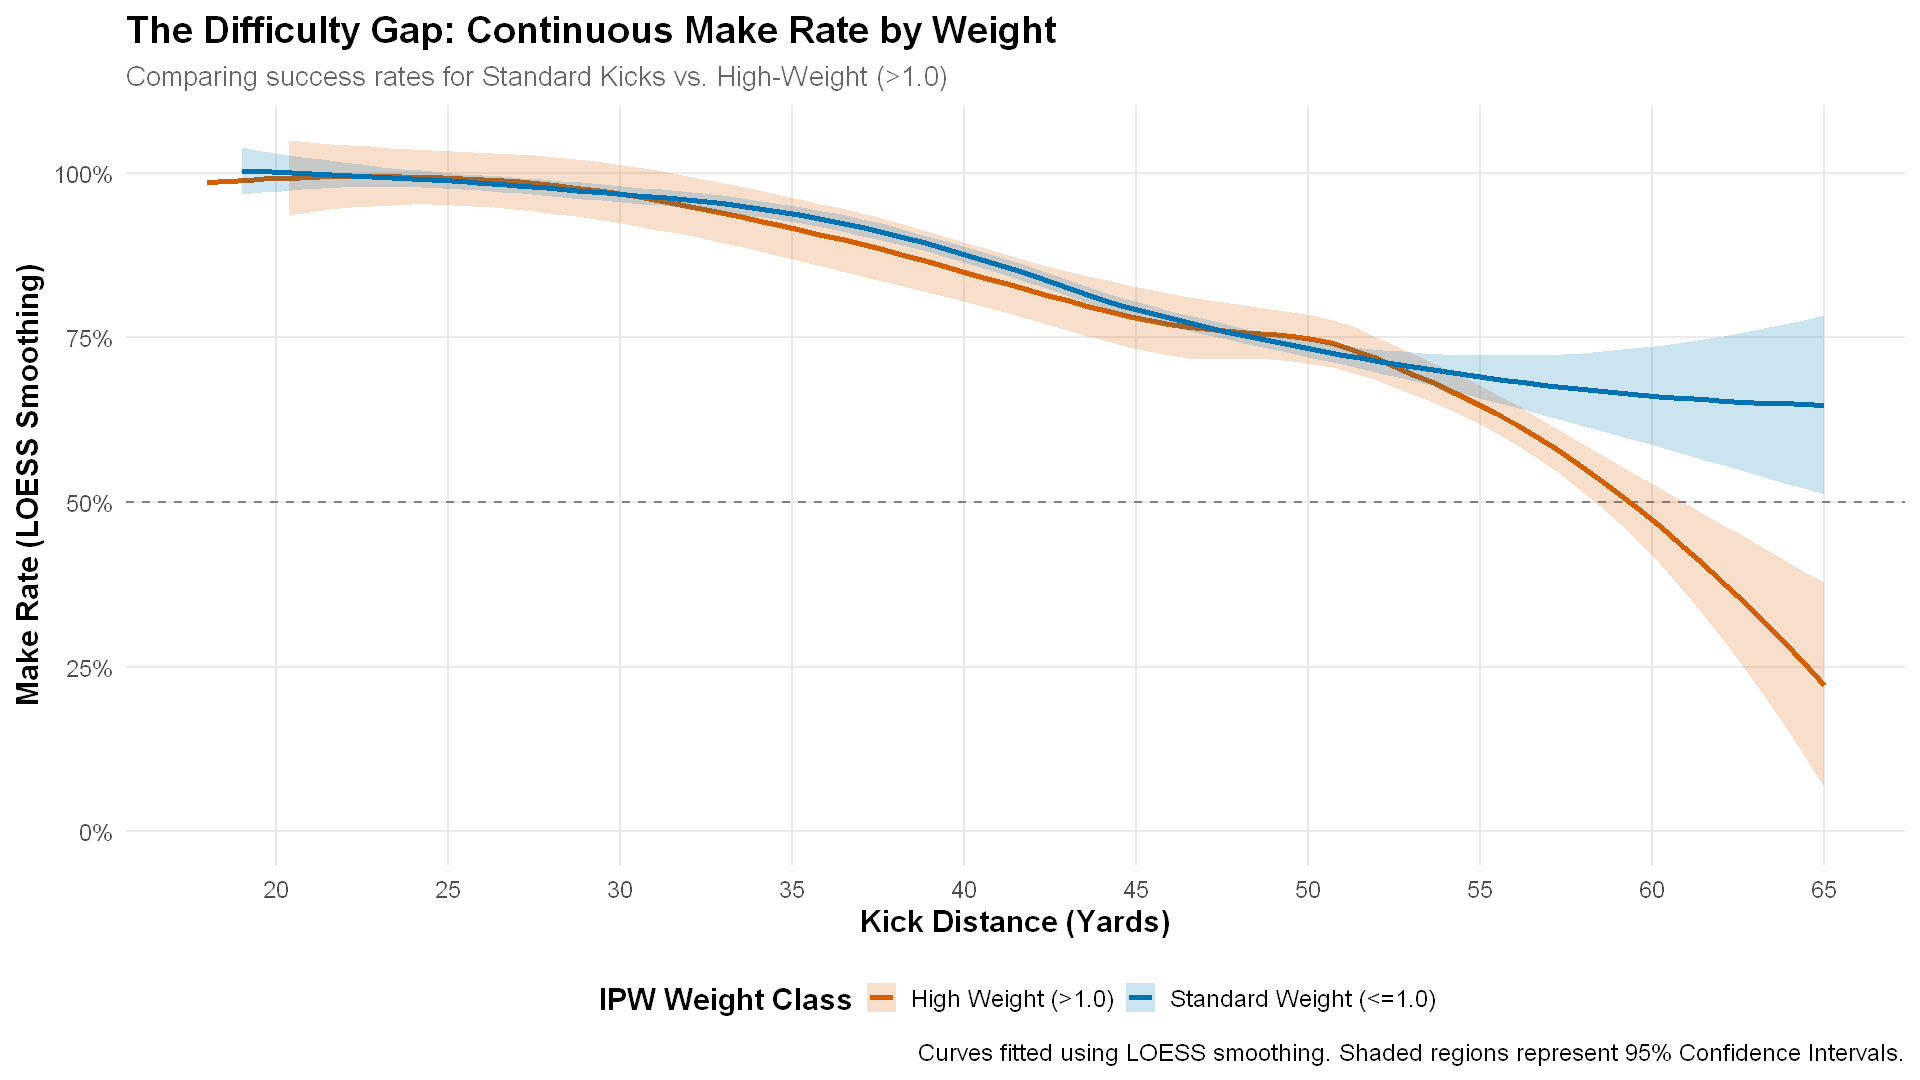

In [89]:
library(tidyverse)

# ==============================================================================
# Continuous Analysis: Make Rate by Distance (Weight Split > 1.0)
# ==============================================================================

# 1. Prepare Data
# We plot the raw binary data (0/1). Geom_smooth calculates the probability P(Make).
loess_data <- fg_full_pooled %>%
  dplyr::filter(kick_distance <= 65) %>% # Cap at 65 to avoid noisy tail artifacts
  dplyr::mutate(
    Weight_Category = ifelse(weight_multinom_hajek > 1, 
                             "High Weight (>1.0)", 
                             "Standard Weight (<=1.0)")
  )

# 2. Visualization
# Define Palette
weight_cols <- c("Standard Weight (<=1.0)" = "#0072B2", "High Weight (>1.0)" = "#D55E00")

p_weight_loess <- ggplot(loess_data, aes(x = kick_distance, y = kick_made, color = Weight_Category, fill = Weight_Category)) +
  
  # Reference Line (50% Probability)
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "grey50") +
  
  # Continuous Loess Curves
  # method = "loess" on binary data estimates the probability curve
  geom_smooth(method = "loess", span = 0.7, size = 1.5, alpha = 0.2) +
  
  # Formatting
  scale_color_manual(values = weight_cols) +
  scale_fill_manual(values = weight_cols) +
  
  # Axis formatting
  scale_y_continuous(labels = scales::percent, limits = c(0, 1.05)) +
  scale_x_continuous(breaks = seq(20, 65, 5)) +
  
  labs(
    title = "The Difficulty Gap: Continuous Make Rate by Weight",
    subtitle = "Comparing success rates for Standard Kicks vs. High-Weight (>1.0)",
    x = "Kick Distance (Yards)",
    y = "Make Rate (LOESS Smoothing)",
    color = "IPW Weight Class",
    fill = "IPW Weight Class",
    caption = "Curves fitted using LOESS smoothing. Shaded regions represent 95% Confidence Intervals."
  ) +
  
  # Theme (16:9 Optimized)
  theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(face = "bold", size = 22),
    plot.subtitle = element_text(size = 16, color = "grey40"),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    axis.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

# Display
options(repr.plot.width = 16, repr.plot.height = 9)
print(p_weight_loess)

# Save
if(exists("reports_dir")) {
  ggsave(file.path(reports_dir, "weight_impact_continuous_loess.png"), p_weight_loess, width = 16, height = 9)
}

In [79]:
library(tidyverse)
library(knitr)

# ==============================================================================
# Expanded Table: Kick Performance by Weight Class (45-65 yards)
# ==============================================================================

# 1. Filter and Aggregate
expanded_table <- fg_full_pooled %>%
  # Filter for the requested distance range
  filter(kick_distance >= 45, kick_distance <= 65) %>%
  
  # Create 5-yard bins
  mutate(
    bin = cut(kick_distance, 
              breaks = c(45, 50, 55, 60, 66), 
              right = FALSE, 
              labels = c("45-49 yds", "50-54 yds", "55-59 yds", "60-65 yds"))
  ) %>%
  
  # Group by Bin
  group_by(bin) %>%
  summarise(
    # --- Split 1: Threshold > 1.0 ---
    `Count (W <= 1)` = sum(weight_multinom_hajek <= 1, na.rm = TRUE),
    `Make % (W <= 1)` = mean(kick_made[weight_multinom_hajek <= 1], na.rm = TRUE),
    
    `Count (W > 1)` = sum(weight_multinom_hajek > 1, na.rm = TRUE),
    `Make % (W > 1)` = mean(kick_made[weight_multinom_hajek > 1], na.rm = TRUE),
    
    # --- Split 2: Threshold > 2.0 ---
    `Count (W <= 2)` = sum(weight_multinom_hajek <= 2, na.rm = TRUE),
    `Make % (W <= 2)` = mean(kick_made[weight_multinom_hajek <= 2], na.rm = TRUE),
    
    `Count (W > 2)` = sum(weight_multinom_hajek > 2, na.rm = TRUE),
    `Make % (W > 2)` = mean(kick_made[weight_multinom_hajek > 2], na.rm = TRUE),
    
    .groups = 'drop'
  ) %>%
  
  # Format Percentages
  mutate(
    `Make % (W <= 1)` = scales::percent(`Make % (W <= 1)`, accuracy = 0.1),
    `Make % (W > 1)` = scales::percent(`Make % (W > 1)`, accuracy = 0.1),
    `Make % (W <= 2)` = scales::percent(`Make % (W <= 2)`, accuracy = 0.1),
    `Make % (W > 2)` = scales::percent(`Make % (W > 2)`, accuracy = 0.1)
  )

# 2. Display Table
cat("\n--- Comprehensive Weight Impact Table (45-65 Yards) ---\n")
print(kable(expanded_table, align = "c"))


--- Comprehensive Weight Impact Table (45-65 Yards) ---


|    bin    | Count (W <= 1) | Make % (W <= 1) | Count (W > 1) | Make % (W > 1) | Count (W <= 2) | Make % (W <= 2) | Count (W > 2) | Make % (W > 2) |
|:---------:|:--------------:|:---------------:|:-------------:|:--------------:|:--------------:|:---------------:|:-------------:|:--------------:|
| 45-49 yds |      1404      |      75.5%      |      159      |     74.8%      |      1542      |      75.4%      |      21       |     81.0%      |
| 50-54 yds |      883       |      72.9%      |      445      |     71.7%      |      1238      |      72.9%      |      90       |     66.7%      |
| 55-59 yds |       55       |      65.5%      |      402      |     59.5%      |      221       |      62.0%      |      236      |     58.5%      |
| 60-65 yds |       3        |      33.3%      |      64       |     39.1%      |       9        |      44.4%      |      58       |     37.9%      |



--- Model A: Baseline (Distance Only) ---
# A tibble: 1 × 5
  term          estimate std.error statistic   p.value
  <chr>            <dbl>     <dbl>     <dbl>     <dbl>
1 kick_distance   -0.112   0.00362     -30.9 5.38e-209
# A tibble: 1 × 9
  set     brier logloss   auc calib_error accuracy precision recall f1_score
  <chr>   <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>    <dbl>
1 Model A 0.106   0.342 0.775      0.0205    0.863     0.866  0.995    0.926

--- Model B: The 'Unicorn' Effect (Distance + Weight) ---
# A tibble: 1 × 5
  term   estimate std.error statistic p.value
  <chr>     <dbl>     <dbl>     <dbl>   <dbl>
1 weight   0.0150    0.0276     0.545   0.586
# A tibble: 1 × 9
  set     brier logloss   auc calib_error accuracy precision recall f1_score
  <chr>   <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>    <dbl>
1 Model B 0.106   0.342 0.775      0.0202    0.863     0.865  0.997    0.926

--- Model C: The Mechanism Check (Distance + Environment + W

`geom_smooth()` using formula = 'y ~ x'


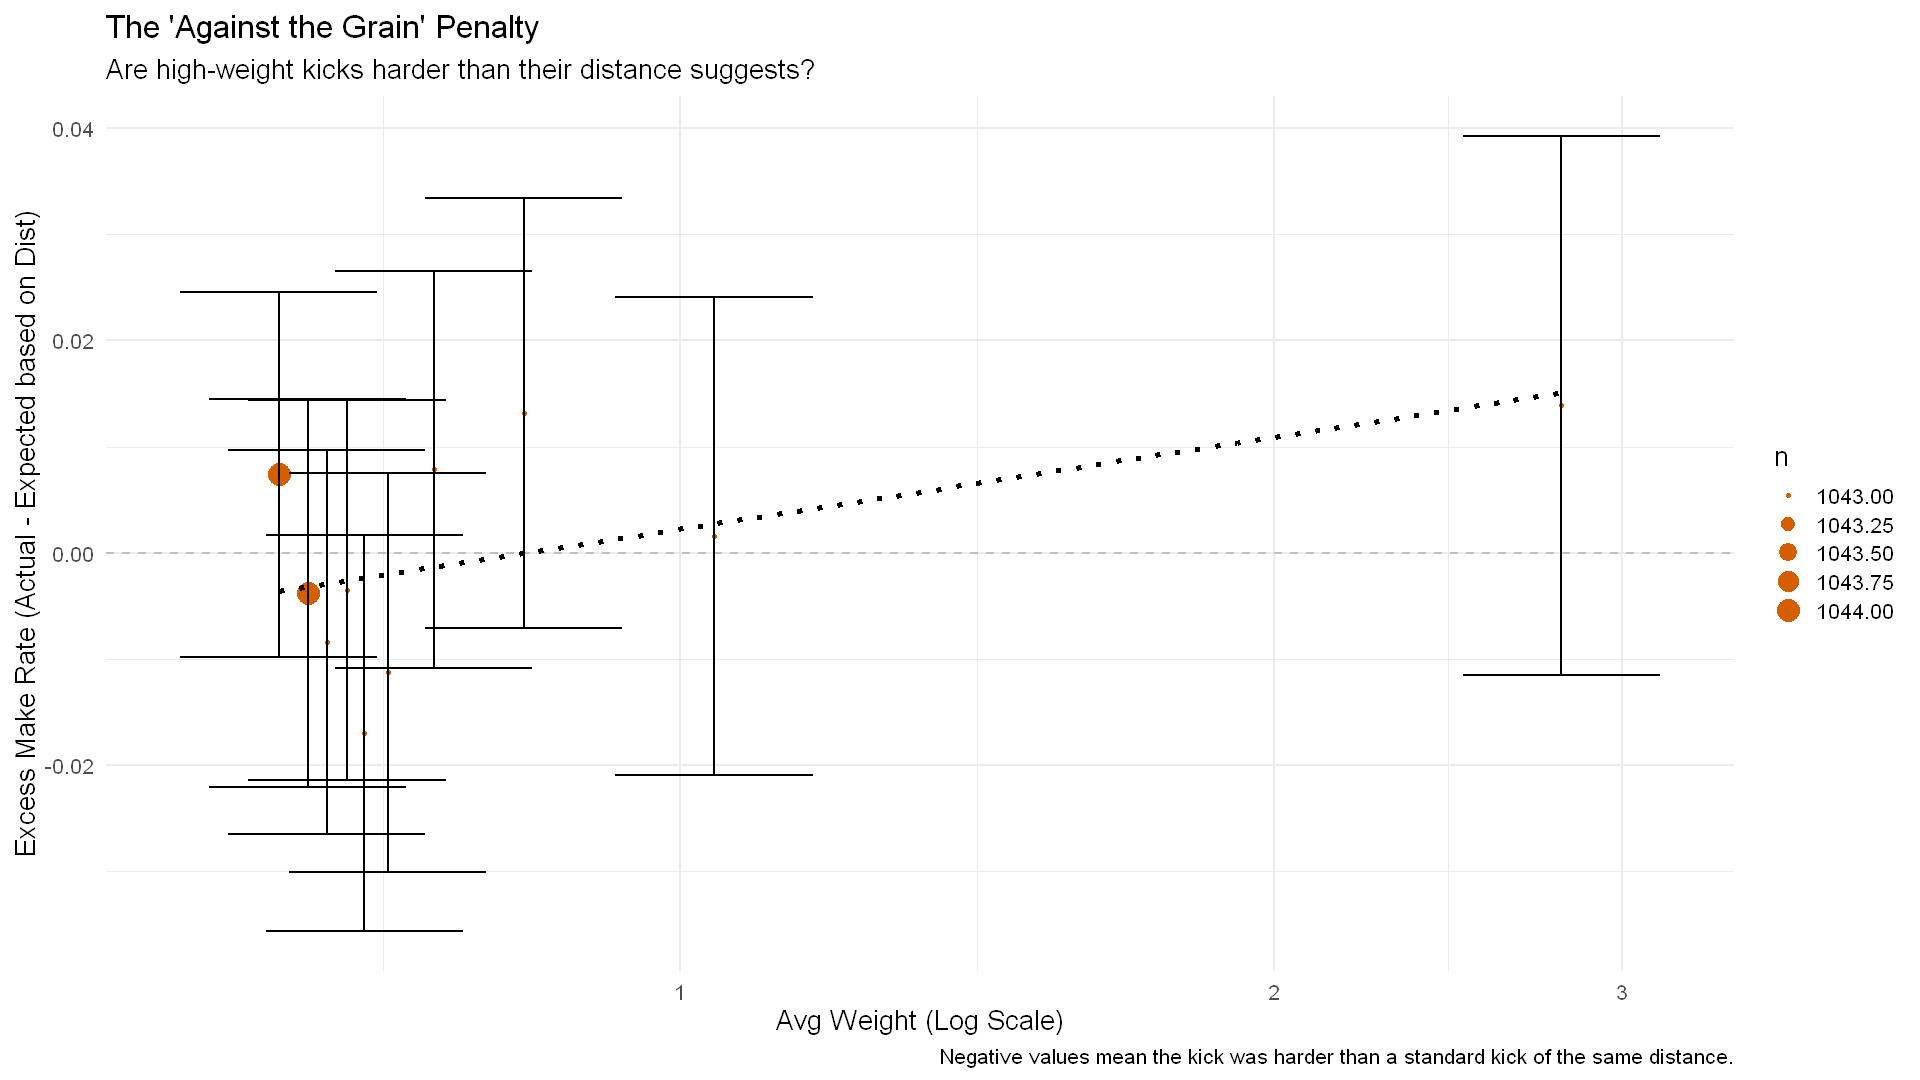

In [87]:
library(tidyverse)
library(broom)

# ==============================================================================
# Robust Evaluation: The "Against the Grain" Penalty
# ==============================================================================

# 1. Prepare Data
# Log-transform weight because it is highly skewed (right-tailed)
reg_data <- fg_full_pooled %>%
  filter(!is.na(weight_multinom_hajek), !is.na(kick_distance)) %>%
  mutate(
    log_weight = log(weight_multinom_hajek),
    weight = weight_multinom_hajek,
    # Ensure Environmental variables are present (impute 0/mean if missing for this quick check)
    wind_z = if_else(is.na(wind_z), 0, wind_z),
    temp_z = if_else(is.na(temp_z), 0, temp_z),
    is_rain = if_else(is.na(is_rain_showers), 0, is_rain_showers),
    is_snow = if_else(is.na(is_snow_sleet), 0, is_snow_sleet)
  )

# 2. Run Logistic Regressions
# ------------------------------------------------------------------------------

# Model A: Baseline (Distance Only)
m_dist <- glm(kick_made ~ kick_distance, data = reg_data, family = "binomial")

# Model B: The "Unicorn" Effect (Distance + Weight)
# If log_weight is NEGATIVE and SIGNIFICANT, high-weight kicks are harder.
m_weight <- glm(kick_made ~ kick_distance + weight, data = reg_data, family = "binomial")

# Model C: The Mechanism Check (Distance + Environment + Weight)
# Does Weight still matter after we verify it's not just Wind/Temp?
m_env <- glm(kick_made ~ kick_distance + wind_z + temp_z + is_rain + is_snow + weight, data = reg_data, family = "binomial")

#Model summary and metric comparison
cat("\n--- Model A: Baseline (Distance Only) ---\n")
print(tidy(m_dist) %>% filter(term == "kick_distance"))
print(calc_metrics(reg_data$kick_made, predict(m_dist, type = "response"), "Model A"))

cat("\n--- Model B: The 'Unicorn' Effect (Distance + Weight) ---\n")
print(tidy(m_weight) %>% filter(term == "weight"))
print(calc_metrics(reg_data$kick_made, predict(m_weight, type = "response"), "Model B"))

cat("\n--- Model C: The Mechanism Check (Distance + Environment + Weight) ---\n")
print(tidy(m_env) %>% filter(term == "weight"))
print(calc_metrics(reg_data$kick_made, predict(m_env, type = "response"), "Model C"))

# 3. Compare Results
# ------------------------------------------------------------------------------
cat("\n--- Model B: Does Weight predict failure (controlling for distance)? ---\n")
print(tidy(m_weight) %>% filter(term == "weight"))

cat("\n--- Model C: Is Weight just a proxy for bad weather? ---\n")
print(tidy(m_env) %>% filter(term == "weight"))

# 4. Visualization: Distance-Adjusted Residuals
# ------------------------------------------------------------------------------
# We calculate the "Residual" (Actual Make - Expected Make given Distance)
# If High Weight kicks are harder, their residuals should be negative.

reg_data$expected_make_dist <- predict(m_dist, type = "response")
reg_data$residual <- reg_data$kick_made - reg_data$expected_make_dist

# Bin weights for plotting
plot_resid <- reg_data %>%
  mutate(
    Weight_Bin = ntile(weight_multinom_hajek, 10), # Deciles
    Is_High_Weight = weight_multinom_hajek > 2
  ) %>%
  group_by(Weight_Bin) %>%
  summarise(
    Avg_Weight = mean(weight_multinom_hajek),
    Avg_Residual = mean(residual),
    n = n(),
    se = sd(residual) / sqrt(n)
  )

# Plot
p_resid <- ggplot(plot_resid, aes(x = Avg_Weight, y = Avg_Residual)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
  geom_point(aes(size = n), color = "#D55E00") +
  geom_errorbar(aes(ymin = Avg_Residual - 1.96*se, ymax = Avg_Residual + 1.96*se), width = 0.1) +
  geom_smooth(method = "lm", color = "black", se = FALSE, linetype = "dotted") +
  scale_x_log10() + # Log scale for weight
  labs(
    title = "The 'Against the Grain' Penalty",
    subtitle = "Are high-weight kicks harder than their distance suggests?",
    x = "Avg Weight (Log Scale)",
    y = "Excess Make Rate (Actual - Expected based on Dist)",
    caption = "Negative values mean the kick was harder than a standard kick of the same distance."
  ) +
  theme_minimal(base_size = 16)

print(p_resid)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


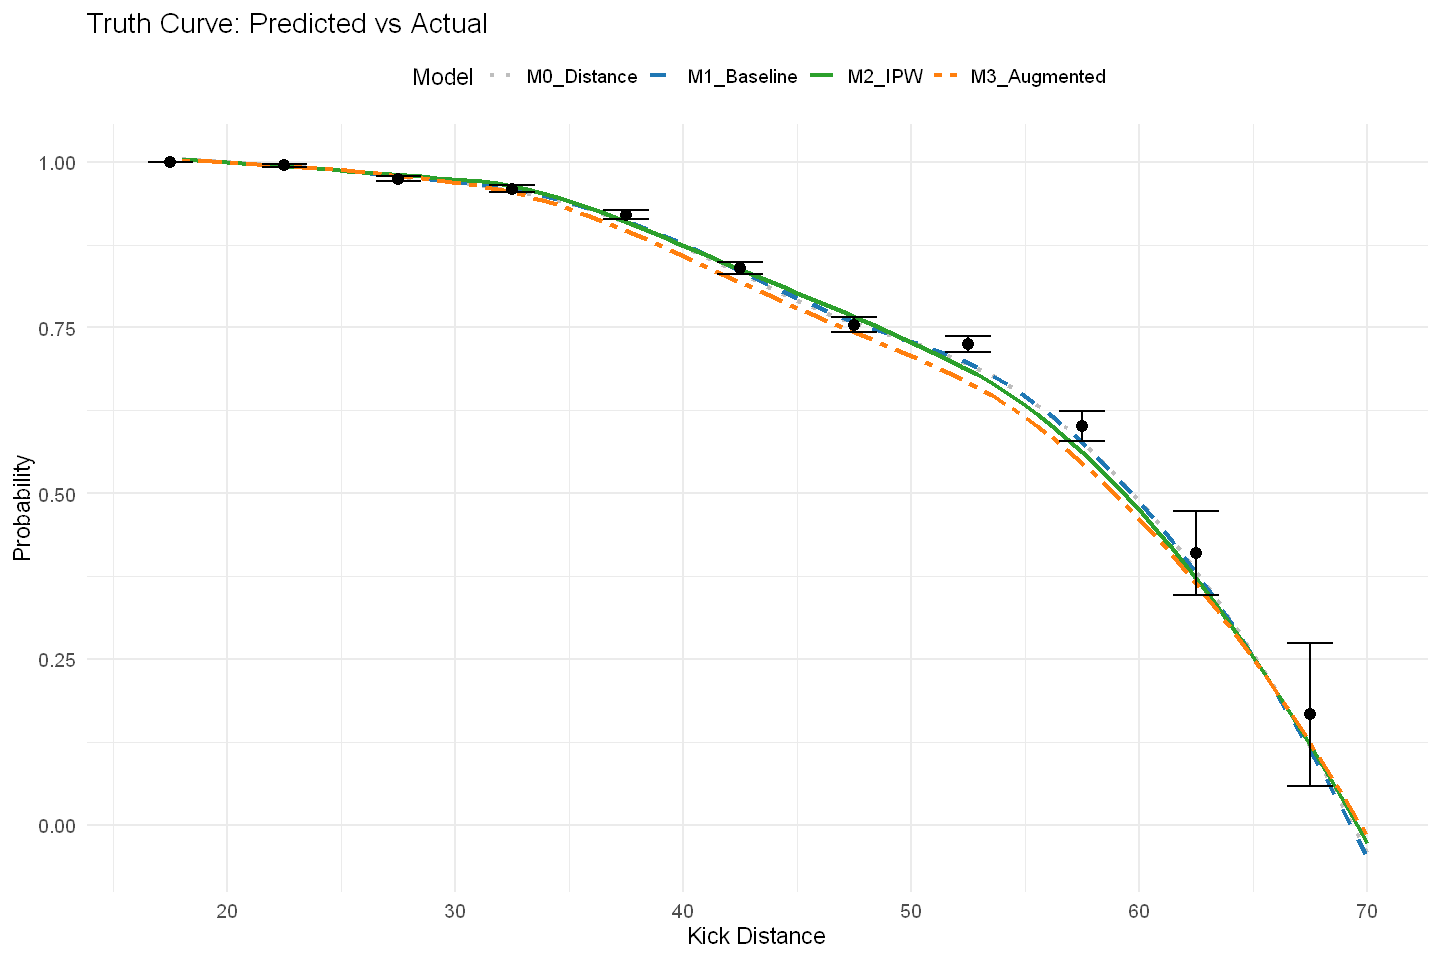

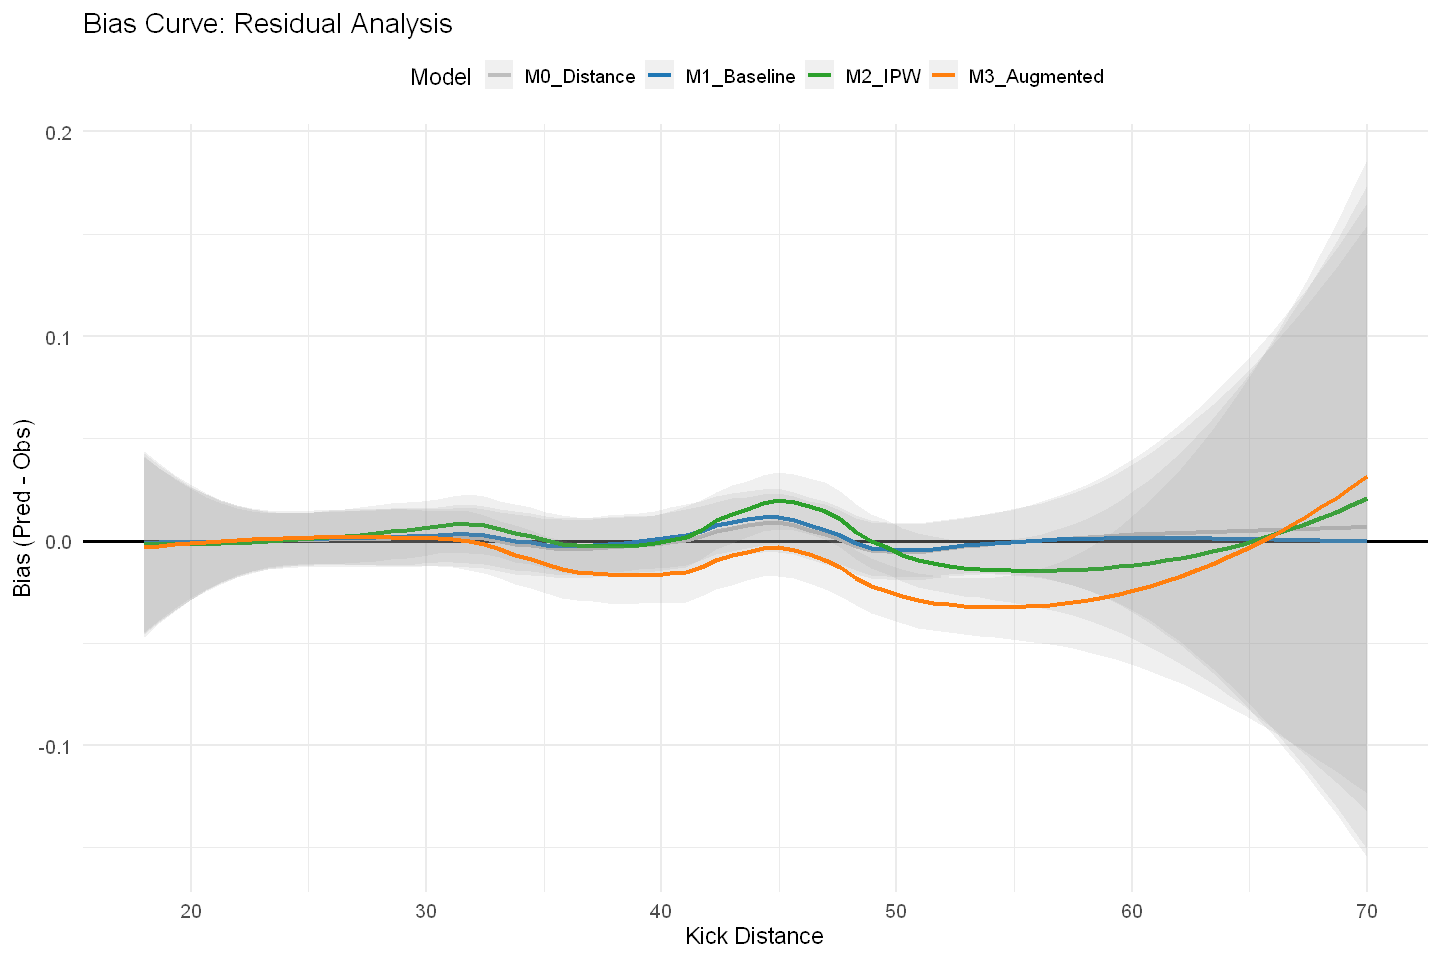

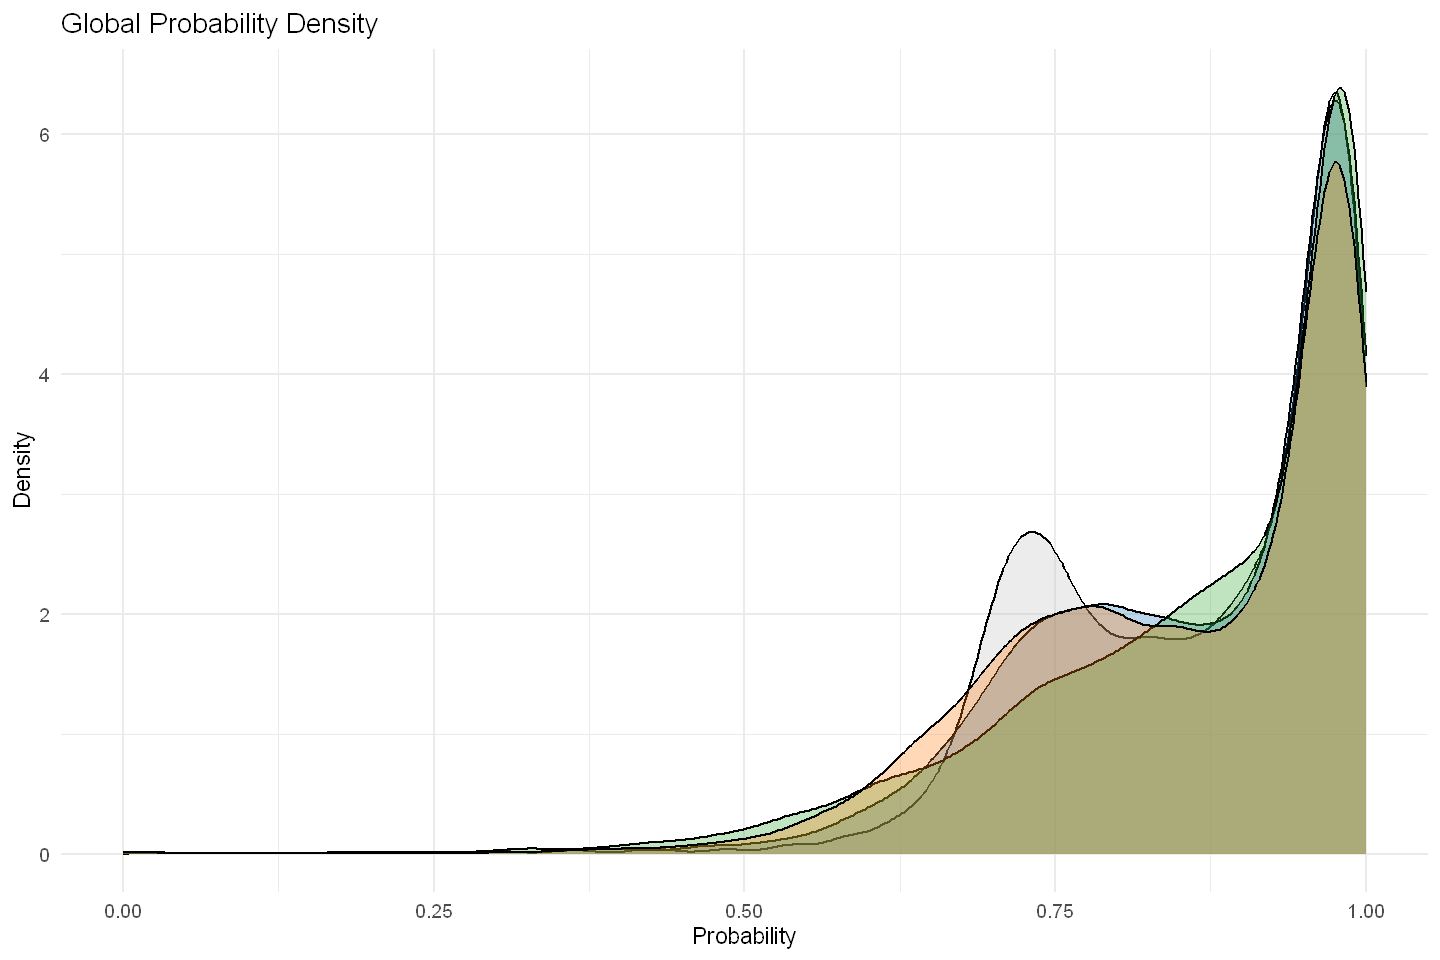

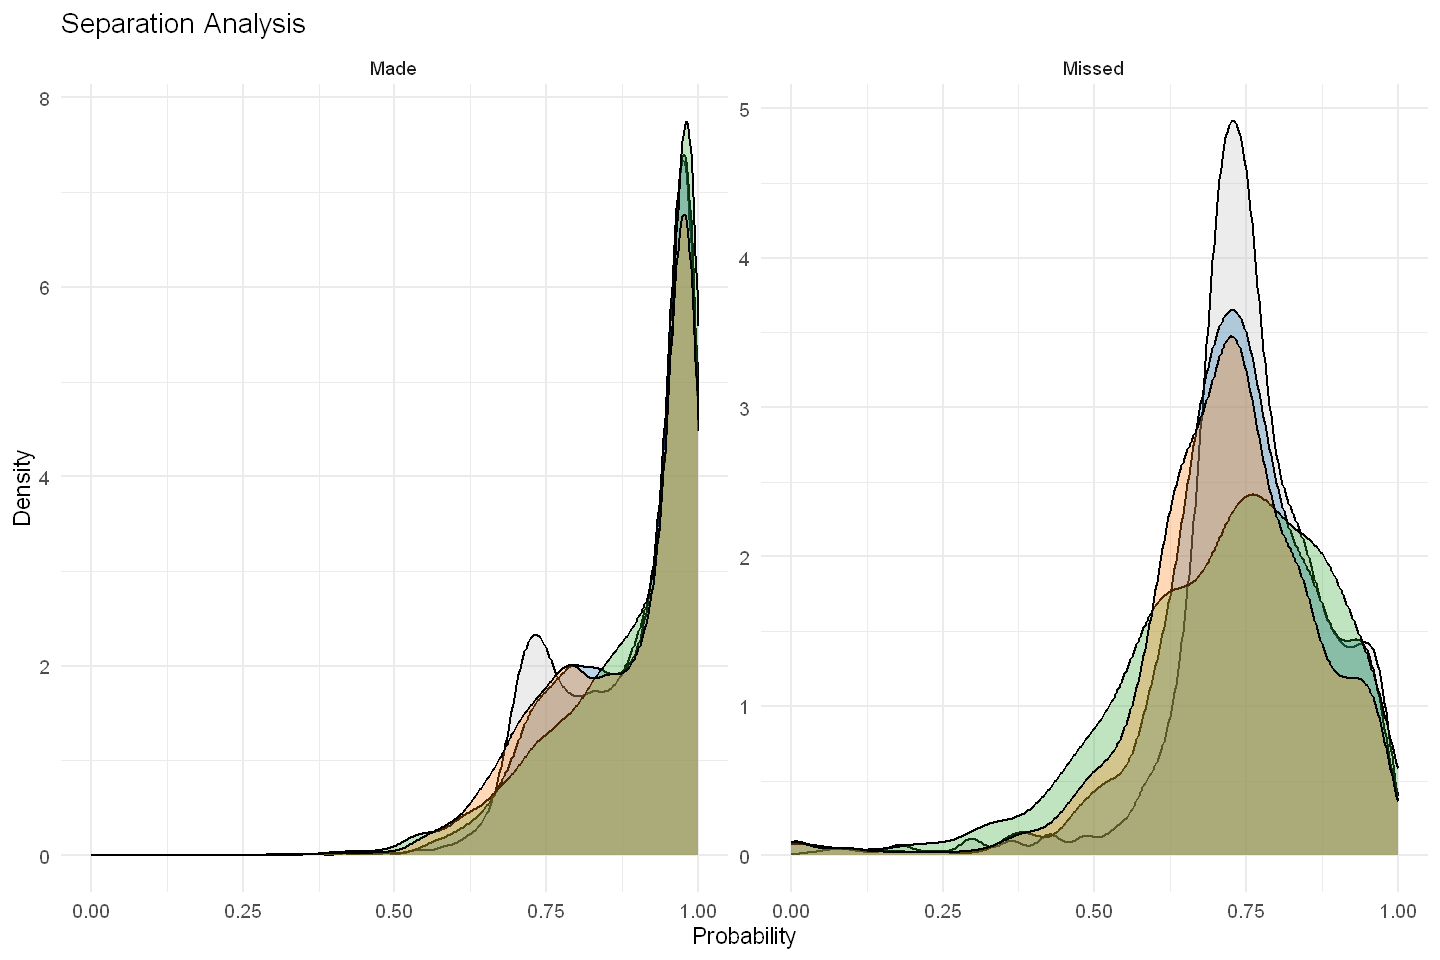

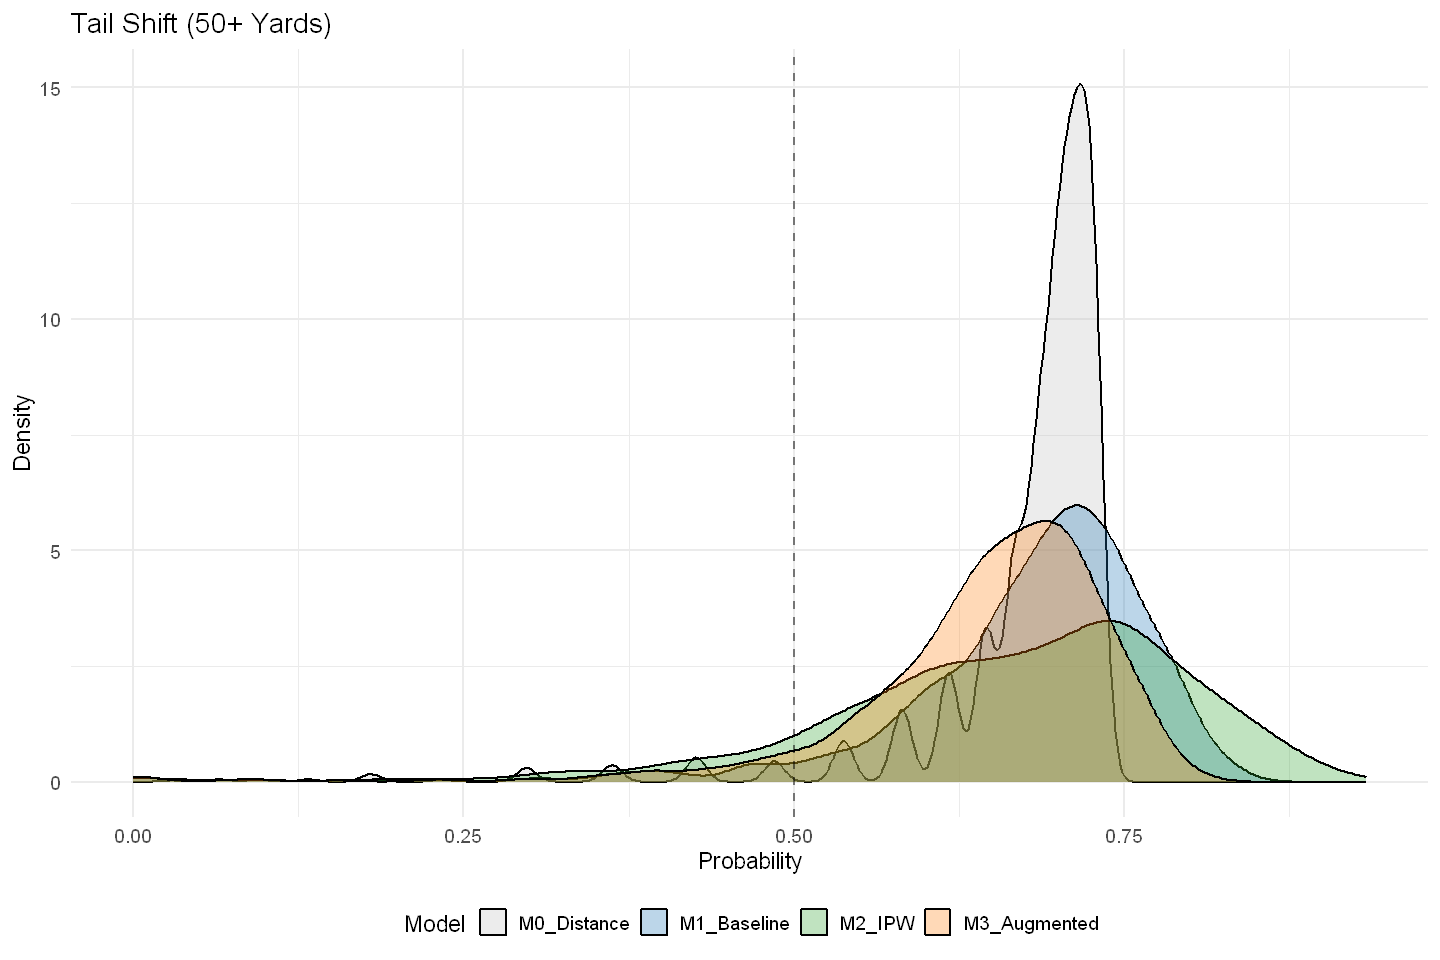

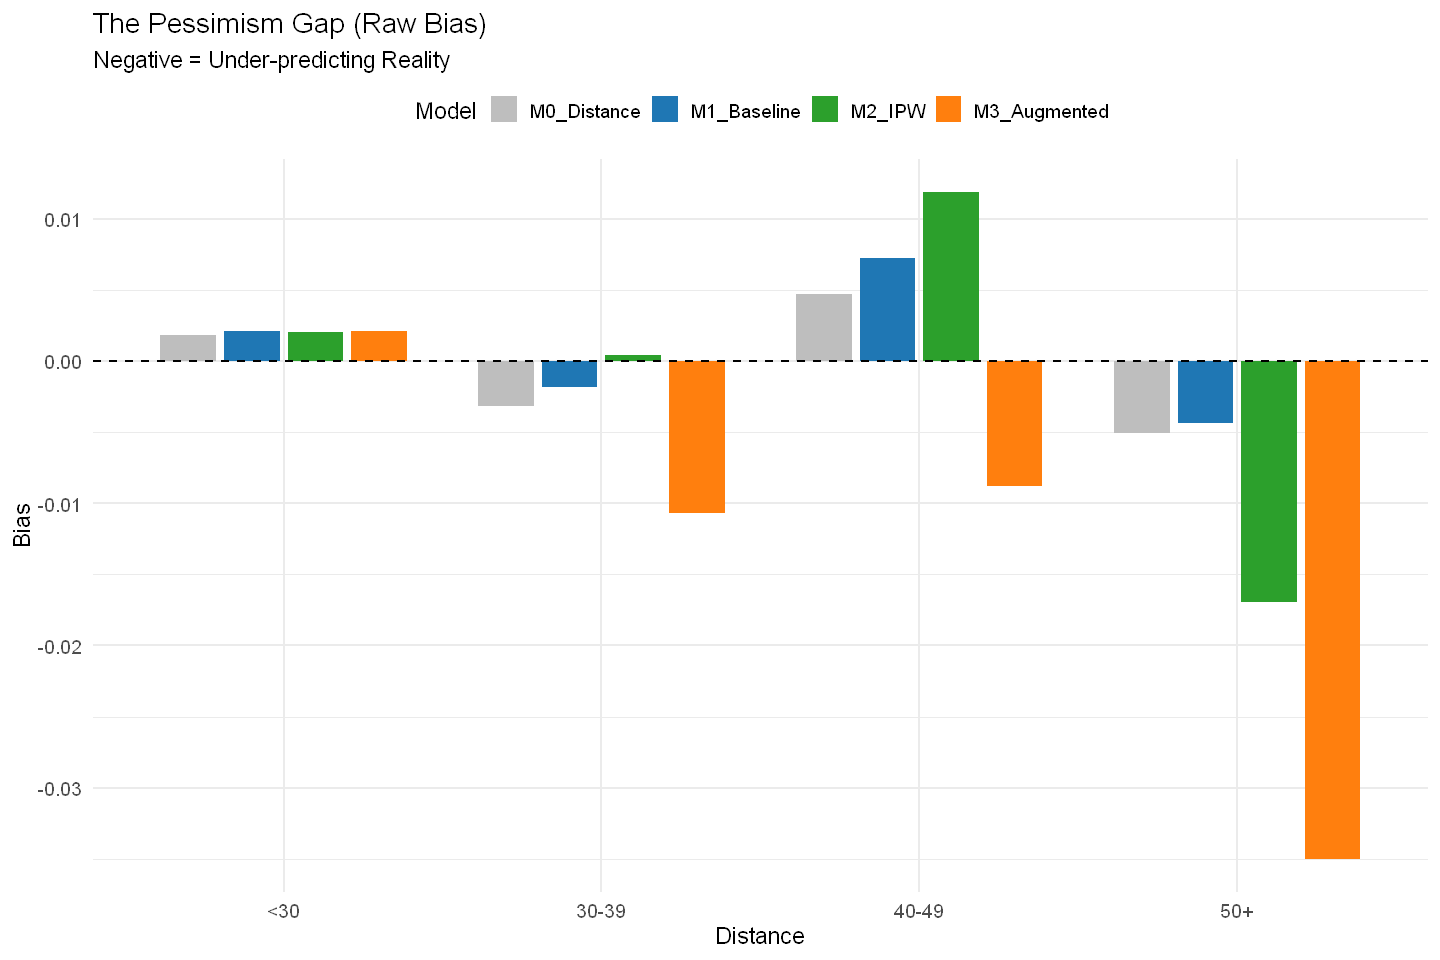

In [23]:
# ==============================================================================
# 1. Setup & Data Prep
# ==============================================================================

# Define Palette (M0 = Orange, M1 = Blue, M2 = Green)
cols <- c("M0_Distance" = "grey", # Grey
          "M1_Baseline" = "#1f77b4", # Blue
          "M2_IPW"      = "#2ca02c", # Green
          "M3_Augmented" = "#ff7f0e") #Orange

# A. Construct Comparison Dataframe
comparison_df <- fg_full_pooled %>%
  # Select and rename columns directly from the dataframe.
  # This ensures we use the aligned data from the join, not the raw vectors of different lengths.
  dplyr::select(
    kick_made, 
    kick_distance, 
    M0_Distance = pred_m0_full,
    M1_Baseline = pred_m1_full,
    M2_IPW      = pred_m2_full,
    M3_Augmented = pred_m3_full
  ) %>%
  dplyr::mutate(
    # Create bins for summary stats
    dist_bin = dplyr::case_when(
      kick_distance < 30 ~ "<30",
      kick_distance < 40 ~ "30-39",
      kick_distance < 50 ~ "40-49",
      kick_distance >= 50 ~ "50+"
    )
  )

# Force Factor Order
comparison_df$dist_bin <- factor(comparison_df$dist_bin, levels = c("<30", "30-39", "40-49", "50+"))


# B. Calculate Detailed Metrics (Summary Table)
detailed_metrics <- comparison_df %>%
  dplyr::group_by(dist_bin) %>%
  dplyr::summarise(
    n = dplyr::n(),
    
    # Raw Bias (Signed) for Pessimism Gap
    bias_m0 = mean(M0_Distance) - mean(kick_made),
    bias_m1 = mean(M1_Baseline) - mean(kick_made),
    bias_m2 = mean(M2_IPW) - mean(kick_made),
    bias_m3 = mean(M3_Augmented) - mean(kick_made), 
    
    # Calibration Error (Absolute)
    calib_m0 = abs(mean(M0_Distance) - mean(kick_made)),
    calib_m1 = abs(mean(M1_Baseline) - mean(kick_made)),
    calib_m2 = abs(mean(M2_IPW) - mean(kick_made)),
    calib_m3 = abs(mean(M3_Augmented) - mean(kick_made)),
    
    .groups = "drop"
  )

# C. Prepare Binned Truth Data (5-yard buckets)
truth_binned <- comparison_df %>%
  mutate(bin_start = floor(kick_distance / 5) * 5) %>%
  group_by(bin_start) %>%
  summarise(
    n = n(), 
    obs_prob = mean(kick_made),
    se = sqrt((obs_prob * (1 - obs_prob)) / n), 
    .groups = "drop"
  ) %>%
  filter(n > 10)

# D. Prepare Long-Format Data for Plotting
plot_curve_data <- comparison_df %>%
  select(kick_distance, kick_made, M0_Distance, M1_Baseline, M2_IPW, M3_Augmented) %>%
  pivot_longer(cols = c(M0_Distance, M1_Baseline, M2_IPW, M3_Augmented), 
               names_to = "Model", values_to = "Prob")

dist_plot_data <- comparison_df %>%
  select(kick_made, kick_distance, M0_Distance, M1_Baseline, M2_IPW, M3_Augmented, dist_bin) %>%
  pivot_longer(cols = c(M0_Distance, M1_Baseline, M2_IPW, M3_Augmented), 
               names_to = "Model", values_to = "Probability") %>%
  mutate(Outcome = ifelse(kick_made == 1, "Made", "Missed"))

# ==============================================================================
# 2. Plot Generation
# ==============================================================================

# --- Plot 1: The Truth Curve ---
p_truth <- ggplot() +
  # Models (Smooth Lines)
  geom_smooth(data = plot_curve_data, 
              aes(x = kick_distance, y = Prob, color = Model, linetype = Model), 
              method = "loess", span = 0.5, size = 1.2, se = FALSE) +
  # Truth (Points + Error Bars)
  geom_point(data = truth_binned, aes(x = bin_start + 2.5, y = obs_prob), size = 3) +
  geom_errorbar(data = truth_binned, aes(x = bin_start + 2.5, ymin = obs_prob - se, ymax = obs_prob + se), width = 2) +
  # Styling
  scale_color_manual(values = cols) +
  scale_linetype_manual(values = c("dotted", "dashed", "solid", "twodash")) +
  labs(title = "Truth Curve: Predicted vs Actual", x = "Kick Distance", y = "Probability") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# --- Plot 2: The Bias Curve ---
p_bias <- ggplot(plot_curve_data %>% mutate(Residual = Prob - kick_made), 
                 aes(x = kick_distance, y = Residual, color = Model)) +
  geom_hline(yintercept = 0, color = "black", size = 1) +
  geom_smooth(method = "loess", span = 0.5, se = TRUE, alpha = 0.15, size = 1.2) +
  scale_color_manual(values = cols) +
  labs(title = "Bias Curve: Residual Analysis", x = "Kick Distance", y = "Bias (Pred - Obs)") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# --- Plot 3: Global Density ---
p_dens_global <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  scale_fill_manual(values = cols) +
  labs(title = "Global Probability Density", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# --- Plot 4: Separation Analysis ---
p_dens_sep <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  facet_wrap(~Outcome, scales = "free_y") +
  scale_fill_manual(values = cols) +
  labs(title = "Separation Analysis", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "none")

# --- Plot 5: Tail Shift (50+ Yards) ---
p_dens_tail <- ggplot(dist_plot_data %>% filter(dist_bin == "50+"), aes(x = Probability, fill = Model)) +
  geom_density(alpha = 0.3) +
  scale_fill_manual(values = cols) +
  geom_vline(xintercept = 0.5, linetype="dashed", alpha=0.5) +
  labs(title = "Tail Shift (50+ Yards)", x = "Probability", y = "Density") +
  theme_minimal(base_size = 14) + theme(legend.position = "bottom")

# --- Plot 6: Pessimism Gap (Bar Chart) ---
bias_bar_data <- detailed_metrics %>%
  select(dist_bin, starts_with("bias")) %>%
  pivot_longer(cols = -dist_bin, names_to = c("Metric", "Model"), names_sep = "_") %>%
  mutate(Model = case_when(Model == "m0" ~ "M0_Distance", Model == "m1" ~ "M1_Baseline", Model == "m2" ~ "M2_IPW", Model == "m3" ~ "M3_Augmented"))

p_bar_bias <- ggplot(bias_bar_data, aes(x = dist_bin, y = value, fill = Model)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
  scale_fill_manual(values = cols) +
  labs(title = "The Pessimism Gap (Raw Bias)", subtitle = "Negative = Under-predicting Reality", x = "Distance", y = "Bias") +
  theme_minimal(base_size = 14) + theme(legend.position = "top")

# ==============================================================================
# 3. Display
# ==============================================================================

options(repr.plot.width = 12, repr.plot.height = 8)
print(p_truth)
print(p_bias)
print(p_dens_global)
print(p_dens_sep)
print(p_dens_tail)
print(p_bar_bias)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


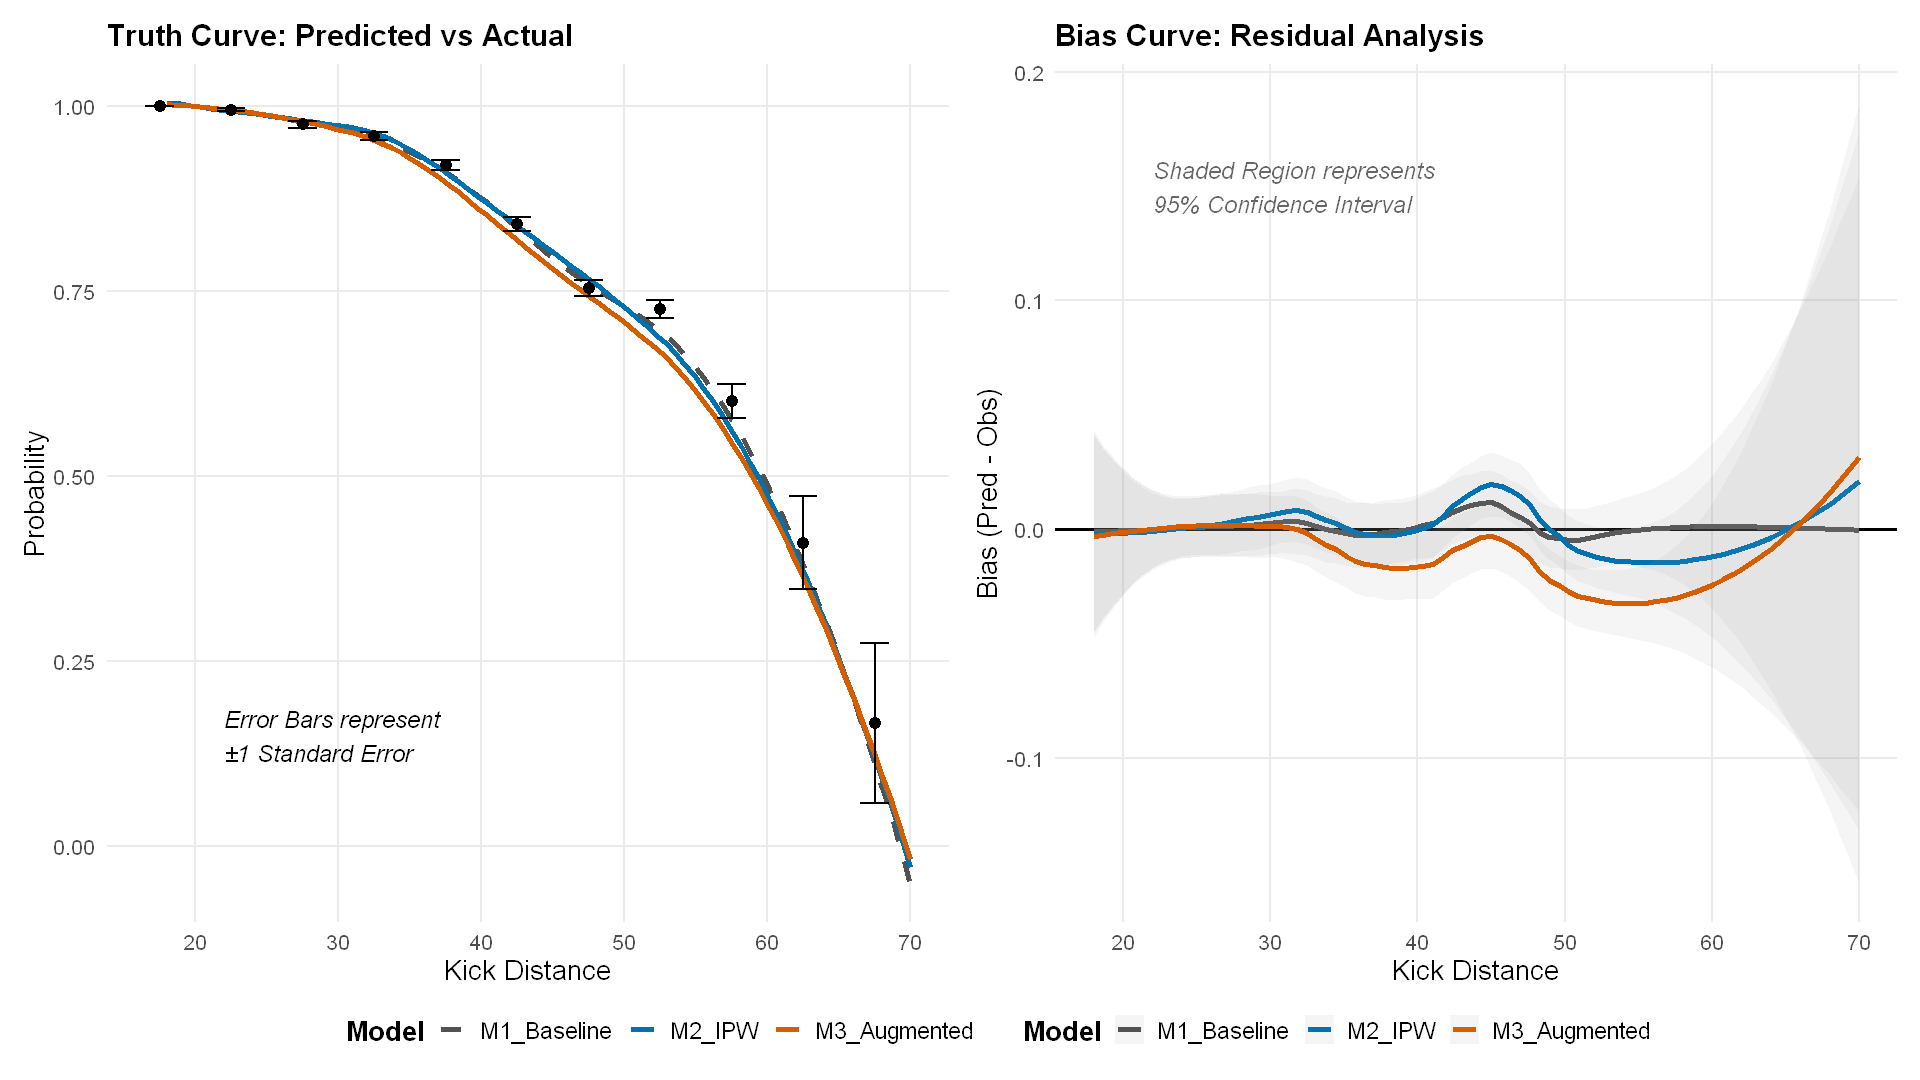

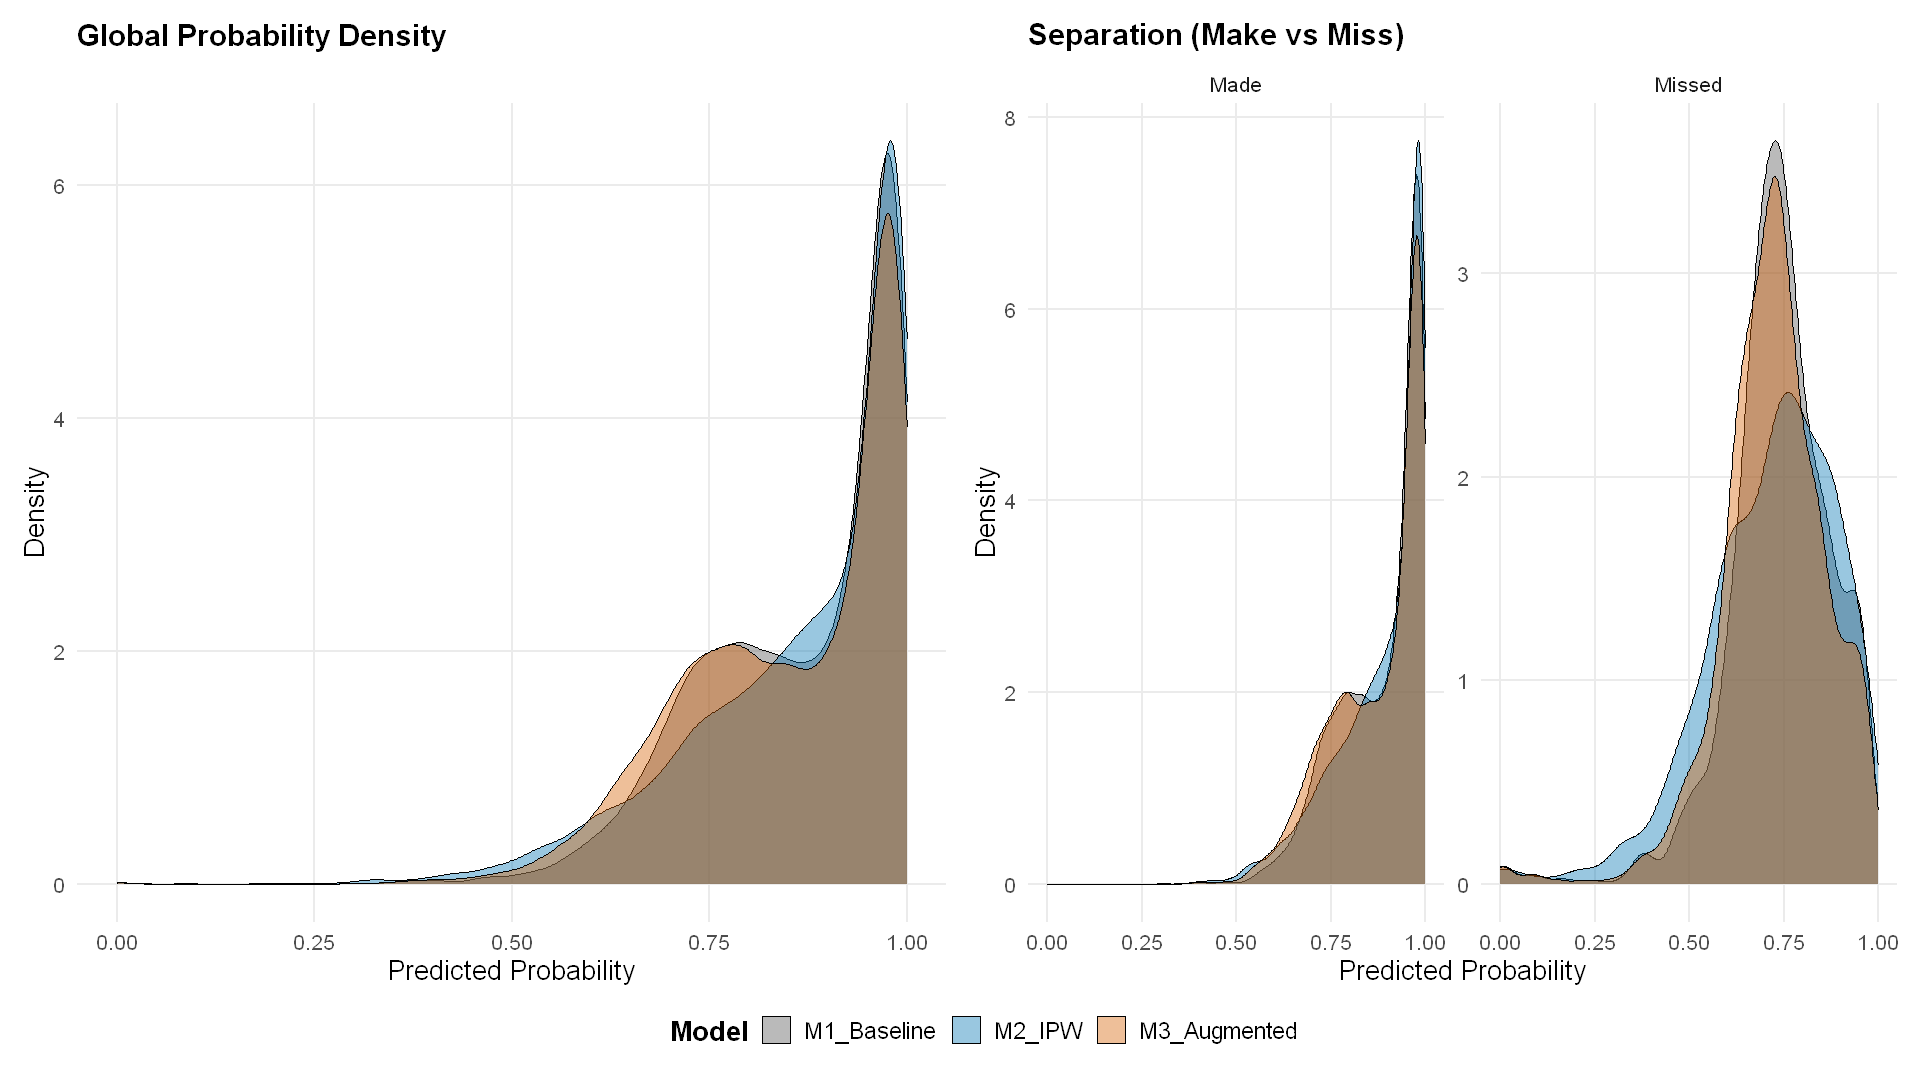

In [30]:
library(tidyverse)
library(patchwork) # Required for combining plots side-by-side

# ==============================================================================
# 1. Setup & Data Prep
# ==============================================================================

# ==============================================================================
# Accessible 3-Color Palette (Okabe-Ito Inspired)
# ==============================================================================
cols <- c(
  "M1_Baseline"  = "#525252", # Dark Grey (Neutral anchor, high contrast against white)
  "M2_IPW"       = "#0072B2", # Strong Blue (Standard accessible blue)
  "M3_Augmented" = "#D55E00"  # Vermilion (Vibrant Red-Orange, distinct from blue)
)

# A. Construct Comparison Dataframe
comparison_df <- fg_full_pooled %>%
  dplyr::select(
    kick_made, 
    kick_distance, 
    M1_Baseline = pred_m1_full,
    M2_IPW      = pred_m2_full,
    M3_Augmented = pred_m3_full
  ) %>%
  dplyr::mutate(
    dist_bin = dplyr::case_when(
      kick_distance < 30 ~ "<30",
      kick_distance < 40 ~ "30-39",
      kick_distance < 50 ~ "40-49",
      kick_distance >= 50 ~ "50+"
    )
  )

comparison_df$dist_bin <- factor(comparison_df$dist_bin, levels = c("<30", "30-39", "40-49", "50+"))

# B. Prepare Binned Truth Data (5-yard buckets)
truth_binned <- comparison_df %>%
  mutate(bin_start = floor(kick_distance / 5) * 5) %>%
  group_by(bin_start) %>%
  summarise(
    n = n(), 
    obs_prob = mean(kick_made),
    se = sqrt((obs_prob * (1 - obs_prob)) / n), 
    .groups = "drop"
  ) %>%
  filter(n > 10)

# C. Prepare Long-Format Data for Plotting
plot_curve_data <- comparison_df %>%
  select(kick_distance, kick_made, M1_Baseline, M2_IPW, M3_Augmented) %>%
  pivot_longer(cols = c(M1_Baseline, M2_IPW, M3_Augmented), 
               names_to = "Model", values_to = "Prob")

dist_plot_data <- comparison_df %>%
  select(kick_made, kick_distance, M1_Baseline, M2_IPW, M3_Augmented, dist_bin) %>%
  pivot_longer(cols = c(M1_Baseline, M2_IPW, M3_Augmented), 
               names_to = "Model", values_to = "Probability") %>%
  mutate(Outcome = ifelse(kick_made == 1, "Made", "Missed"))

# ==============================================================================
# 2. Plot Generation
# ==============================================================================

# Common Theme for Large Legends
large_legend_theme <- theme_minimal(base_size = 16) +
  theme(
    legend.position = "bottom",
    legend.title = element_text(face = "bold", size = 16),
    legend.text = element_text(size = 14),
    plot.title = element_text(face = "bold", size = 18),
    #No Grid Lines for Clarity
    panel.grid.minor = element_blank()
  )

library(tidyverse)
library(patchwork) # Required for combining plots side-by-side

# ==============================================================================
# Update: Annotated Truth & Bias Curves
# ==============================================================================

# (Assuming 'plot_curve_data', 'truth_binned', 'bias_data', 'cols', and 'large_legend_theme' 
#  are loaded from the previous step. If not, run the previous block first.)

# --- Plot 1: The Truth Curve (Annotated) ---
p_truth_annotated <- ggplot() +
  # Models (Smooth Lines)
  geom_smooth(data = plot_curve_data, 
              aes(x = kick_distance, y = Prob, color = Model, linetype = Model), 
              method = "loess", span = 0.5, size = 1.5, se = FALSE) +
  
  # Truth (Points + Error Bars)
  geom_point(data = truth_binned, aes(x = bin_start + 2.5, y = obs_prob), size = 3, color = "black") +
  geom_errorbar(data = truth_binned, aes(x = bin_start + 2.5, ymin = obs_prob - se, ymax = obs_prob + se), width = 2, color = "black") +
  
  # ANNOTATION: Explain Error Bars
  annotate("text", x = 22, y = 0.15, label = "Error Bars represent\n±1 Standard Error", 
           hjust = 0, size = 5, fontface = "italic", color = "black") +
  
  # Formatting
  scale_color_manual(values = cols) +
  scale_linetype_manual(values = c("dashed", "solid", "solid")) +
  labs(title = "Truth Curve: Predicted vs Actual", x = "Kick Distance", y = "Probability") +
  large_legend_theme

# --- Plot 2: The Bias Curve (Annotated) ---
p_bias_annotated <- ggplot(bias_data, aes(x = kick_distance, y = Residual, color = Model)) +
  geom_hline(yintercept = 0, color = "black", size = 1) +
  
  # Model Bias Curves with Confidence Intervals
  geom_smooth(method = "loess", span = 0.5, se = TRUE, alpha = 0.1, size = 1.5) +
  
  # ANNOTATION: Explain Shaded Region
  annotate("text", x = 22, y = 0.15, label = "Shaded Region represents\n95% Confidence Interval", 
           hjust = 0, size = 5, fontface = "italic", color = "gray40") +
  
  # Formatting
  scale_color_manual(values = cols) +
  labs(title = "Bias Curve: Residual Analysis", x = "Kick Distance", y = "Bias (Pred - Obs)") +
  large_legend_theme


# --- Plot 3: Global Density (With Outlines) ---
p_dens_global <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  # CHANGE: color = "black" adds the edge, size = 0.3 makes it fine
  geom_density(alpha = 0.4, color = "black", size = 0.3) + 
  scale_fill_manual(values = cols) +
  labs(title = "Global Probability Density", x = "Predicted Probability", y = "Density") +
  large_legend_theme

# --- Plot 4: Separation Analysis (With Outlines) ---
p_dens_sep <- ggplot(dist_plot_data, aes(x = Probability, fill = Model)) +
  # CHANGE: color = "black" adds the edge
  geom_density(alpha = 0.4, color = "black", size = 0.3) +
  facet_wrap(~Outcome, scales = "free_y") +
  scale_fill_manual(values = cols) +
  labs(title = "Separation (Make vs Miss)", x = "Predicted Probability", y = "Density") +
  large_legend_theme


# ==============================================================================
# 3. Final Output (Combined Figures)
# ==============================================================================

# Combine side-by-side
fig1_annotated <- p_truth_annotated + p_bias_annotated + 
  plot_layout(guides = "collect") & theme(legend.position = 'bottom')

# Display
options(repr.plot.width = 16, repr.plot.height = 9)
print(fig1_annotated)

# Save
if(exists("reports_dir")) {
  ggsave(file.path(reports_dir, "M1_M2_M3_Accuracy_Bias_Annotated.png"), fig1_annotated, width = 16, height = 9)
}

# Define Layout Size
options(repr.plot.width = 16, repr.plot.height = 9)

# Combine side-by-side
fig2_outlined <- p_dens_global + p_dens_sep + 
  plot_layout(guides = "collect") & theme(legend.position = 'bottom')

# Display
print(fig2_outlined)

# Save
if(exists("reports_dir")) {
  ggsave(file.path(reports_dir, "M1_M2_M3_Distributions_Outlined.png"), fig2_outlined, width = 16, height = 9)
}

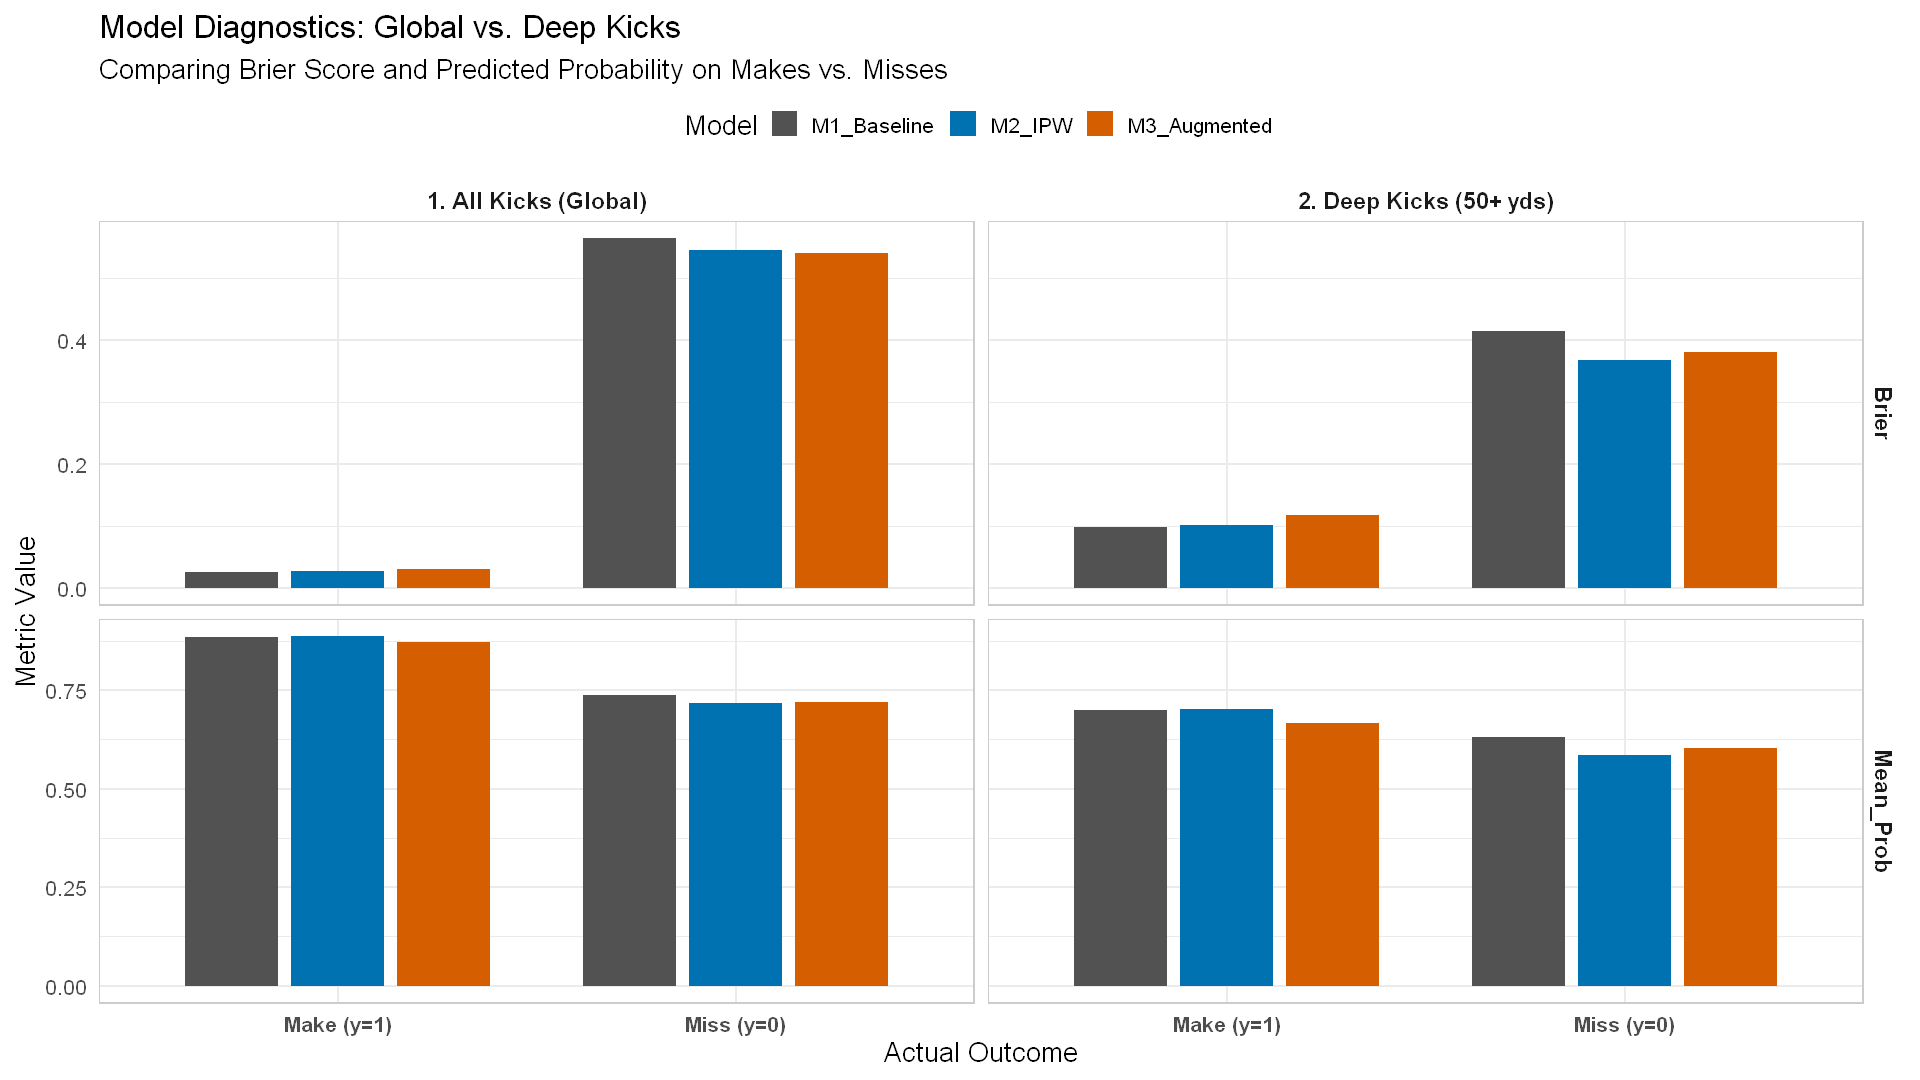

In [28]:
library(tidyverse)

# ==============================================================================
# 1. Calculate Metrics (Global vs. Deep 50+)
# ==============================================================================

# Helper function to calculate metrics
calc_metrics_subset <- function(data, subset_name) {
  data %>%
    dplyr::select(kick_made, M1_Baseline, M2_IPW, M3_Augmented) %>%
    tidyr::pivot_longer(
      cols = c(M1_Baseline, M2_IPW, M3_Augmented),
      names_to = "Model", 
      values_to = "Prob"
    ) %>%
    dplyr::mutate(Outcome_Label = ifelse(kick_made == 1, "Make (y=1)", "Miss (y=0)")) %>%
    dplyr::group_by(Model, Outcome_Label) %>%
    dplyr::summarise(
      Mean_Prob = mean(Prob),
      Brier = mean((kick_made - Prob)^2),
      .groups = "drop"
    ) %>%
    dplyr::mutate(Subset = subset_name)
}

# A. Global Data (All Kicks)
metrics_global <- calc_metrics_subset(comparison_df, "1. All Kicks (Global)")

# B. Deep Kicks Only (>= 50 Yards)
metrics_deep <- calc_metrics_subset(comparison_df %>% filter(kick_distance >= 50), "2. Deep Kicks (50+ yds)")

# C. Combine and Reshape
plot_data <- bind_rows(metrics_global, metrics_deep) %>%
  tidyr::pivot_longer(
    cols = c(Brier, Mean_Prob),
    names_to = "Metric",
    values_to = "Value"
  )

# ==============================================================================
# 2. Visualization
# ==============================================================================


# Plot
p_split_metrics <- ggplot(plot_data, aes(x = Outcome_Label, y = Value, fill = Model)) +
  
  # Bar Chart
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), width = 0.7) +
  
  # Faceting: Rows = Metric (Brier vs Prob), Columns = Subset (All vs 50+)
  facet_grid(Metric ~ Subset, scales = "free_y") +
  
  # Styling
  scale_fill_manual(values = cols) +
  labs(
    title = "Model Diagnostics: Global vs. Deep Kicks",
    subtitle = "Comparing Brier Score and Predicted Probability on Makes vs. Misses",
    x = "Actual Outcome",
    y = "Metric Value"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    legend.position = "top",
    strip.text = element_text(face = "bold", size = 14),
    panel.border = element_rect(color = "grey80", fill = NA),
    axis.text.x = element_text(face = "bold")
  )

# Display
options(repr.plot.width = 16, repr.plot.height = 9)
print(p_split_metrics)

# Save
if(exists("reports_dir")) {
  ggsave(file.path(reports_dir, "M1_M2_M3_Metrics_Split_50plus.png"), p_split_metrics, width = 16, height = 9)
}


--- Top 10 Kickers by Difficulty of Workload (Lowest Mean Propensity) ---
# A tibble: 10 × 5
   kicker_player_name n_attempts mean_attempt_prob avg_distance avg_weight
   <chr>                   <int>             <dbl>        <dbl>      <dbl>
 1 B.Aubrey                   83             0.746         41.8      1.41 
 2 W.Reichard                 31             0.753         41.7      1.21 
 3 J.Bates                    30             0.768         41.2      1.21 
 4 J.Slye                    175             0.768         39.6      1.15 
 5 M.Wright                   63             0.781         38.5      1.16 
 6 B.Maher                   143             0.793         39.3      1.18 
 7 E.McPherson               134             0.797         40.5      0.962
 8 M.Prater                  289             0.798         40.6      1.12 
 9 M.Gay                     205             0.799         39.3      1.000
10 G.Zuerlein                327             0.799         39.7      1.14 


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


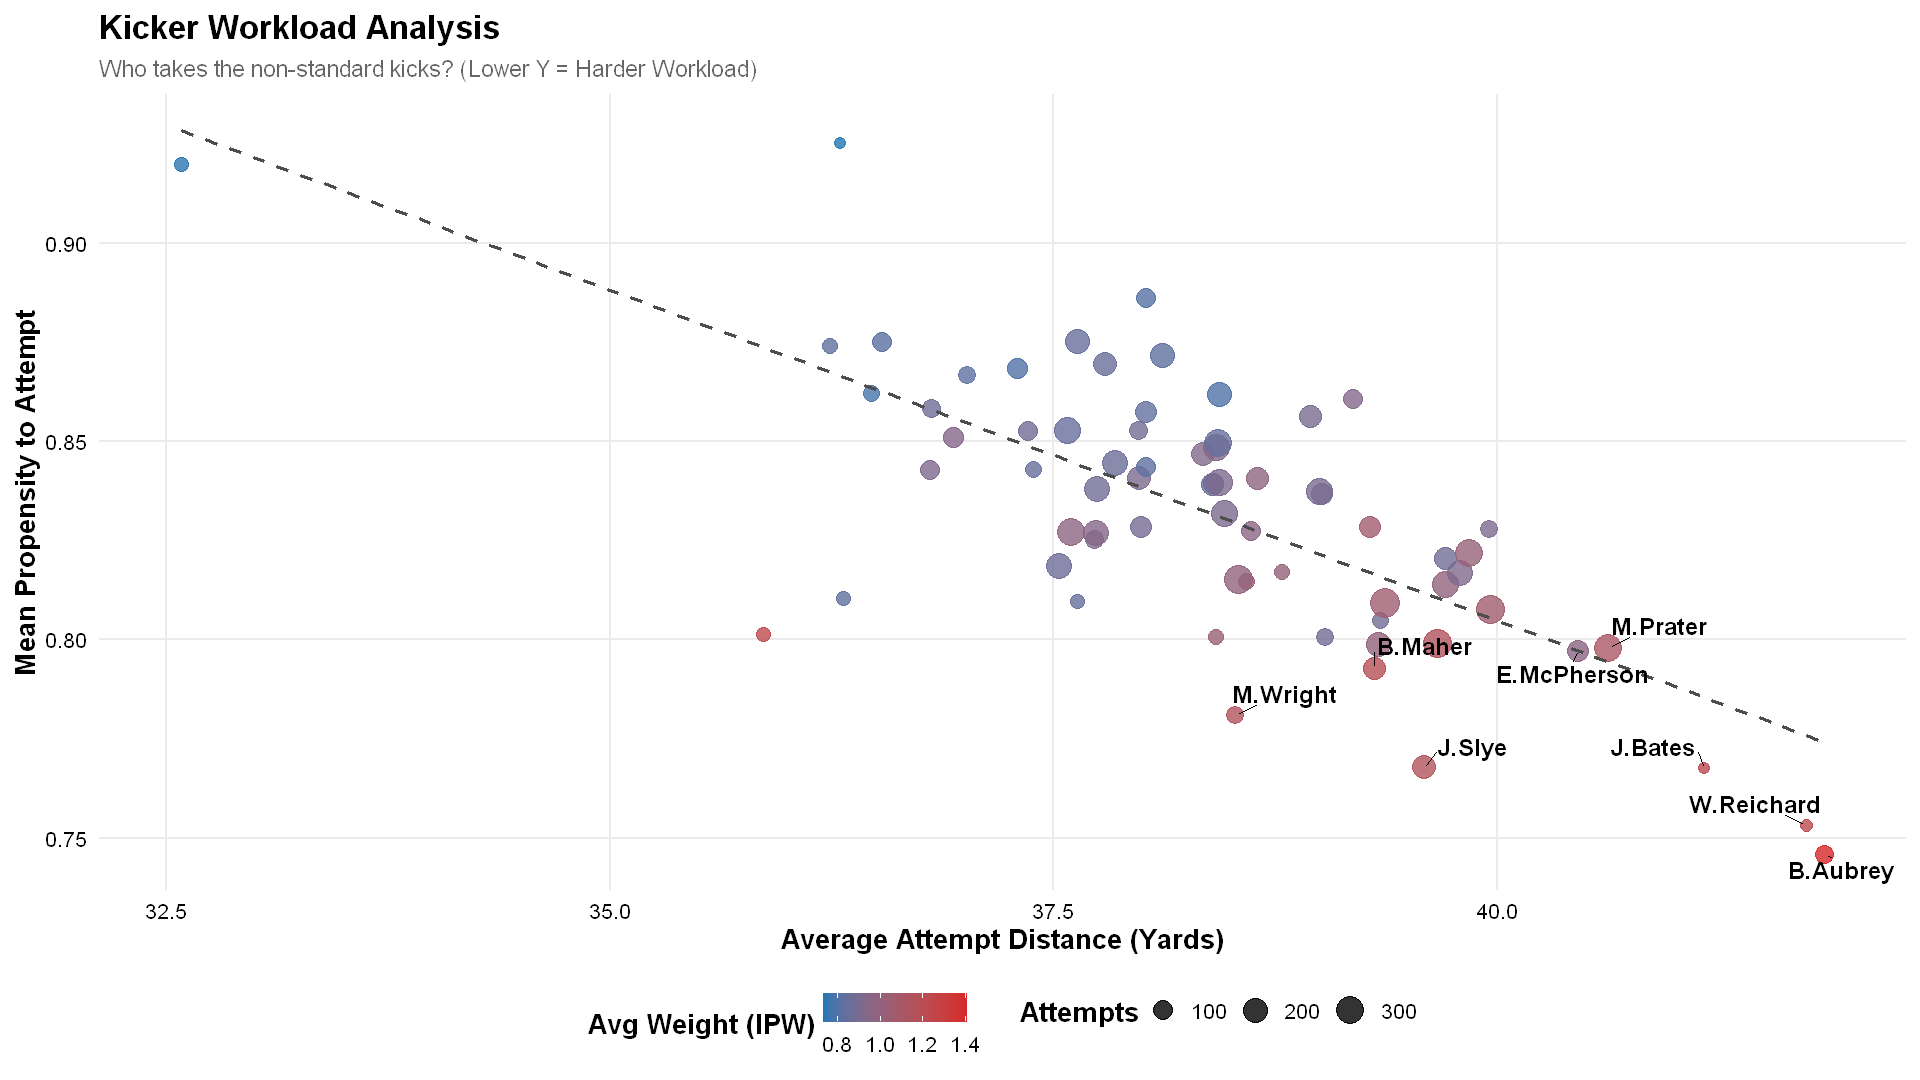

In [33]:
library(tidyverse)
library(ggrepel)

# ==============================================================================
# Kicker Workload Analysis: Propensity vs. Distance
# ==============================================================================

# 1. Calculate Mean Propensity per Kicker
kicker_propensity <- fg_full_pooled %>%
  dplyr::group_by(kicker_player_name) %>%
  dplyr::summarise(
    n_attempts = dplyr::n(),
    
    # The metric: How "standard" are their attempts?
    mean_attempt_prob = mean(p_hat_multinom, na.rm = TRUE),
    
    # Context: What does their workload look like?
    avg_distance = mean(kick_distance, na.rm = TRUE),
    avg_weight = mean(as.numeric(weight_multinom_hajek), na.rm = TRUE),
    
    .groups = "drop"
  ) %>%
  # Filter for sample size to remove noise
  dplyr::filter(n_attempts >= 30) %>%
  dplyr::arrange(mean_attempt_prob) # Rank Low to High

# 2. Display the "Risk Takers"
cat("\n--- Top 10 Kickers by Difficulty of Workload (Lowest Mean Propensity) ---\n")
print(head(kicker_propensity, 10))

# 3. Visualization
p_prop <- ggplot(kicker_propensity, aes(x = avg_distance, y = mean_attempt_prob)) +
  
  # Main Scatter Points (Increased Size range for visibility)
  geom_point(aes(size = n_attempts, color = avg_weight), alpha = 0.8) +
  
  # Trend Line
  geom_smooth(method = "lm", color = "grey30", linetype = "dashed", se = FALSE, size = 1) +
  
  # Labels (Top 8 "Outliers/Risk Takers")
  ggrepel::geom_text_repel(
    data = head(kicker_propensity, 8), 
    aes(label = kicker_player_name), 
    size = 5,                # Increased text size
    fontface = "bold", 
    box.padding = 0.5,
    point.padding = 0.3,
    min.segment.length = 0
  ) +
  
  # Color Scale (High Contrast Gradient)
  scale_color_gradient(low = "#1f77b4", high = "#d62728", name = "Avg Weight (IPW)") +
  
  # Size Scale
  scale_size_continuous(range = c(3, 8), name = "Attempts") +
  
  # Titles & Labels
  labs(
    title = "Kicker Workload Analysis",
    subtitle = "Who takes the non-standard kicks? (Lower Y = Harder Workload)",
    x = "Average Attempt Distance (Yards)",
    y = "Mean Propensity to Attempt"
  ) +
  
  # Theme Improvements for Readability
  theme_minimal(base_size = 16) + # Base size 16 for legible text
  theme(
    plot.title = element_text(face = "bold", size = 20),
    plot.subtitle = element_text(size = 14, color = "grey40"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "black"),
    legend.position = "bottom",
    legend.box = "horizontal",
    legend.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

# Display
options(repr.plot.width = 16, repr.plot.height = 9)
print(p_prop)

# Save
if(exists("reports_dir")) {
  ggsave(file.path(reports_dir, "kicker_workload_propensity.png"), p_prop, width = 16, height = 9)
}

In [37]:
# ==============================================================================
# 1. Robust Formula Construction (Manual Build)
# ==============================================================================

# Load the base model to get terms
m1_model_path <- file.path(models_dir, "m1", "m1_fg_B_logit.rds")
if (!file.exists(m1_model_path)) stop("M1 model not found.")
m1_saved_model <- readRDS(m1_model_path)

# Extract all terms as a character vector
# We use labels() to get the fixed effects strings
all_terms <- labels(terms(m1_saved_model))

# Identify terms to EXCLUDE
# 1. Kicker-Specific terms (Age, Experience, Interactions)
# 2. Existing Random Effects (Anything with "|") to prevent "1 | id" errors
terms_to_drop <- c(
  "high_altitude",
  "indoors",
  "kicker_age_z:kicker_experience_z",
  "kicker_player_id",
  "kicker_age",
  "kicker_experience",
  "|" # Drops all existing REs so we can add them back cleanly
)

ctrl <- glmmTMB::glmmTMBControl(
  optimizer = nlminb, 
  optCtrl = list(iter.max = 1000, eval.max = 1000),
  parallel = 6
)

# Filter the terms list
agnostic_terms <- all_terms
for (drop in terms_to_drop) {
  agnostic_terms <- agnostic_terms[!grepl(drop, agnostic_terms, fixed = TRUE)]
}

# Rebuild the Formula String manually
# 1. Fixed Effects (Splines, Weather, Context)
fixed_effects_str <- paste(agnostic_terms, collapse = " + ")

# 2. Add Agnostic Random Effects (Explicitly with Parentheses)
# We add Stadium (Location) and Season (Era)
agnostic_re_str <- "(1 | stadium_id) + (1 | season)"

# 3. Combine
final_formula_str <- paste("kick_made ~", fixed_effects_str, "+", agnostic_re_str)
m1_agnostic_formula <- as.formula(final_formula_str)

cat("\n--- Corrected M1 Agnostic Formula ---\n")
print(m1_agnostic_formula)

# ==============================================================================
# 2. Fit M1 Agnostic
# ==============================================================================

# Ensure 'season' is a factor for the Random Effect
fg_full_pooled$season <- as.factor(fg_full_pooled$season)

fit_m1_agnostic <- glmmTMB(
  formula = m1_agnostic_formula,
  data = fg_full_pooled,
  family = binomial(link = "logit"),
  control = ctrl
)

# ==============================================================================
# 3. Predict & Evaluate
# ==============================================================================

# Generate Predictions (The "Environment Adjusted Expectation")
cat("Generating predictions...\n")
fg_full_pooled$p_m1_agnostic <- predict_safe(fit_m1_agnostic, fg_full_pooled)

# Calculate Metrics
res_m1_agnostic <- calc_metrics(fg_full_pooled$kick_made, fg_full_pooled$p_m1_agnostic, set_name = "in_sample") %>%
  dplyr::mutate(Model = "M1_Agnostic (No Kicker ID)", .before = 1)

cat("\n--- M1 Agnostic In-Sample Metrics ---\n")
print(res_m1_agnostic)


--- Corrected M1 Agnostic Formula ---
kick_made ~ dist_bs_1 + dist_bs_2 + dist_bs_3 + dist_bs_4 + dist_bs_5 + 
    dist_bs_6 + dist_bs_7 + wind_z + temp_z + is_rain_showers + 
    is_snow_sleet + is_ot + iced + clock_running + posteam_timeouts_remaining + 
    wind_z:temp_z + clock_running:posteam_timeouts_remaining + 
    dist_bs_1:wind_z + dist_bs_2:wind_z + dist_bs_3:wind_z + 
    dist_bs_4:wind_z + dist_bs_5:wind_z + dist_bs_6:wind_z + 
    dist_bs_7:wind_z + dist_bs_1:temp_z + dist_bs_2:temp_z + 
    dist_bs_3:temp_z + dist_bs_4:temp_z + dist_bs_5:temp_z + 
    dist_bs_6:temp_z + dist_bs_7:temp_z + (1 | stadium_id) + 
    (1 | season)
Generating predictions...

--- M1 Agnostic In-Sample Metrics ---
# A tibble: 1 × 10
  Model set   brier logloss   auc calib_error accuracy precision recall f1_score
  <chr> <chr> <dbl>   <dbl> <dbl>       <dbl>    <dbl>     <dbl>  <dbl>    <dbl>
1 M1_A… in_s… 0.103   0.334 0.787     0.00553    0.864     0.866  0.997    0.927



--- Top 10 Kickers by True Skill (Environment Adjusted FGOE) ---
# A tibble: 10 × 9
   kicker_player_name Seasons Attempts Actual_Makes Exp_Makes_Agnostic
   <chr>                <int>    <int>        <dbl>              <dbl>
 1 B.Aubrey                 2       83           77               69.5
 2 C.Dicker                 3      102           96               89.8
 3 J.Tucker                10      368          332              313. 
 4 N.Folk                   9      230          207              199. 
 5 C.McLaughlin             6      150          132              127. 
 6 G.Gano                   9      249          221              213. 
 7 C.Boswell               10      321          289              278. 
 8 J.Sanders                7      218          190              183. 
 9 M.Bryant                 5      134          119              115. 
10 R.Gould                  8      251          227              220. 
# ℹ 4 more variables: FGOE_Total <dbl>, FGOE_Per_Kick <dbl>,
# 

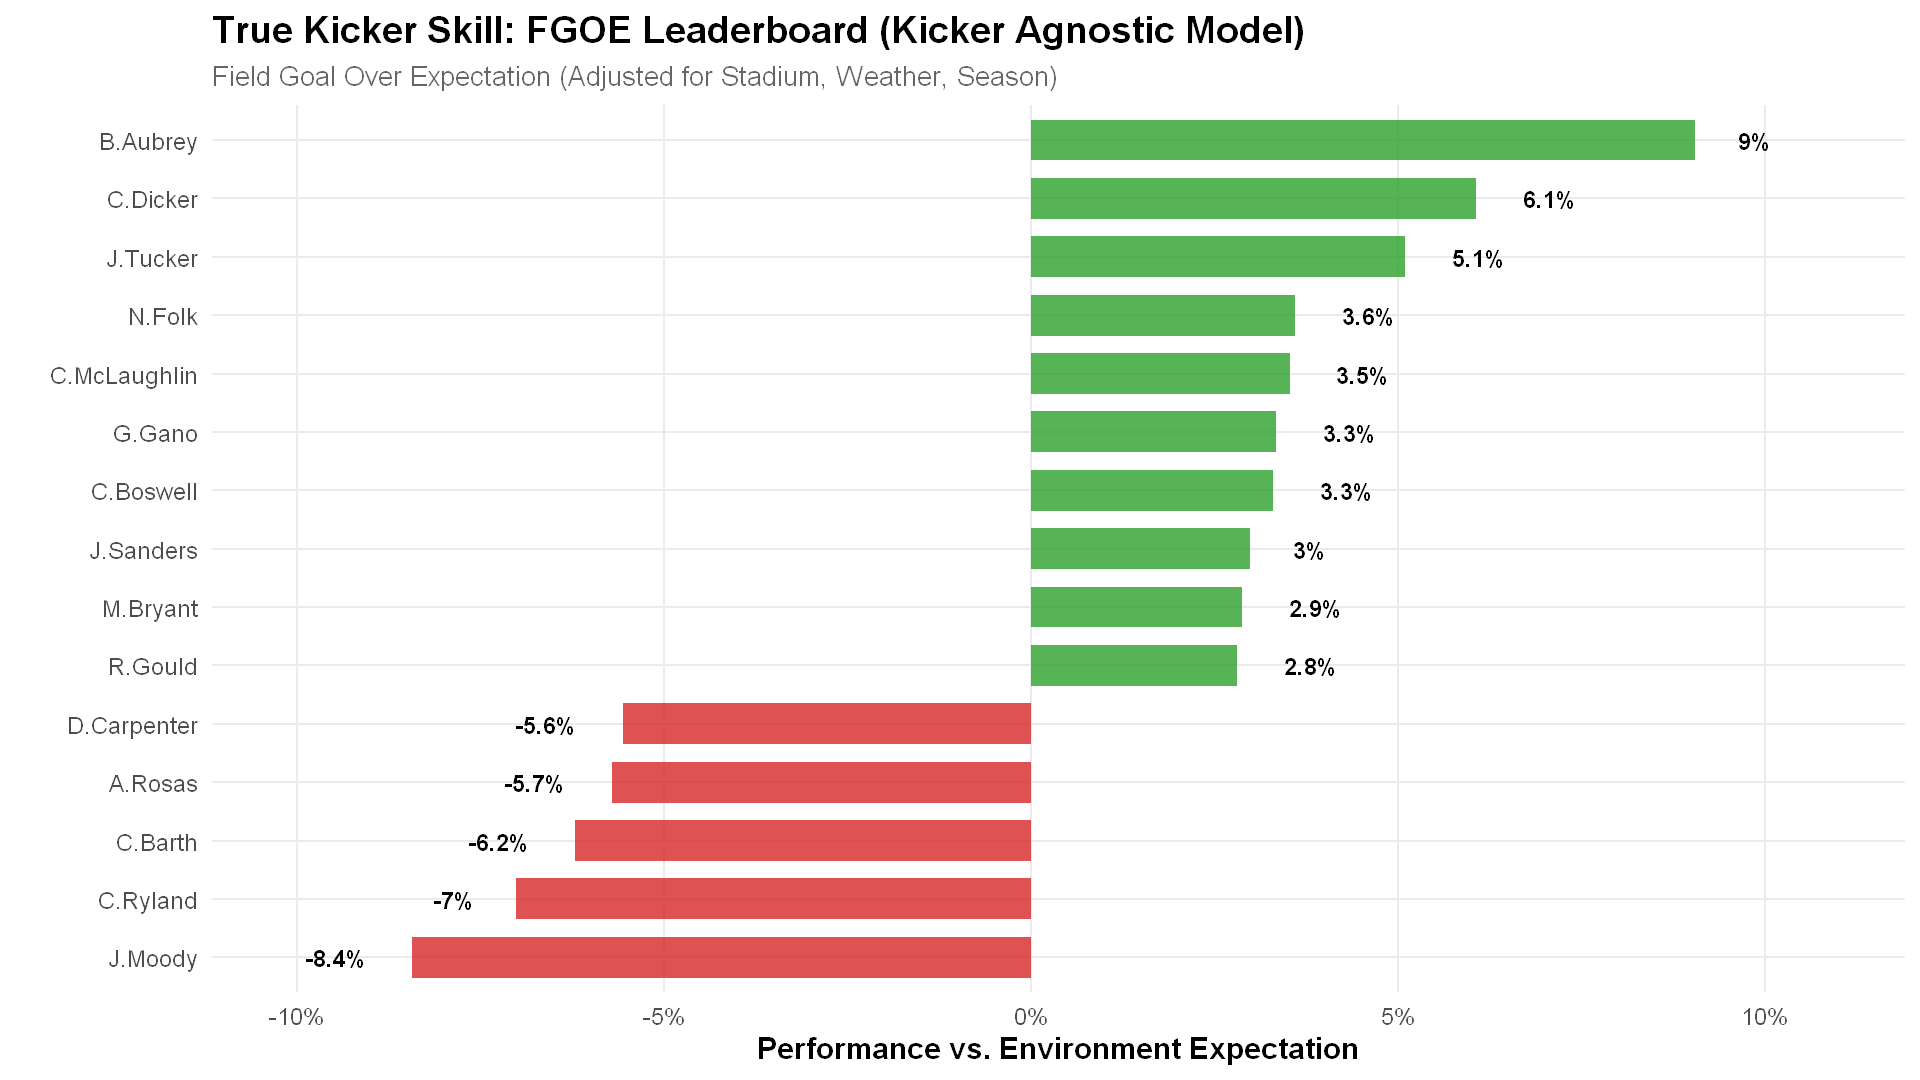

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


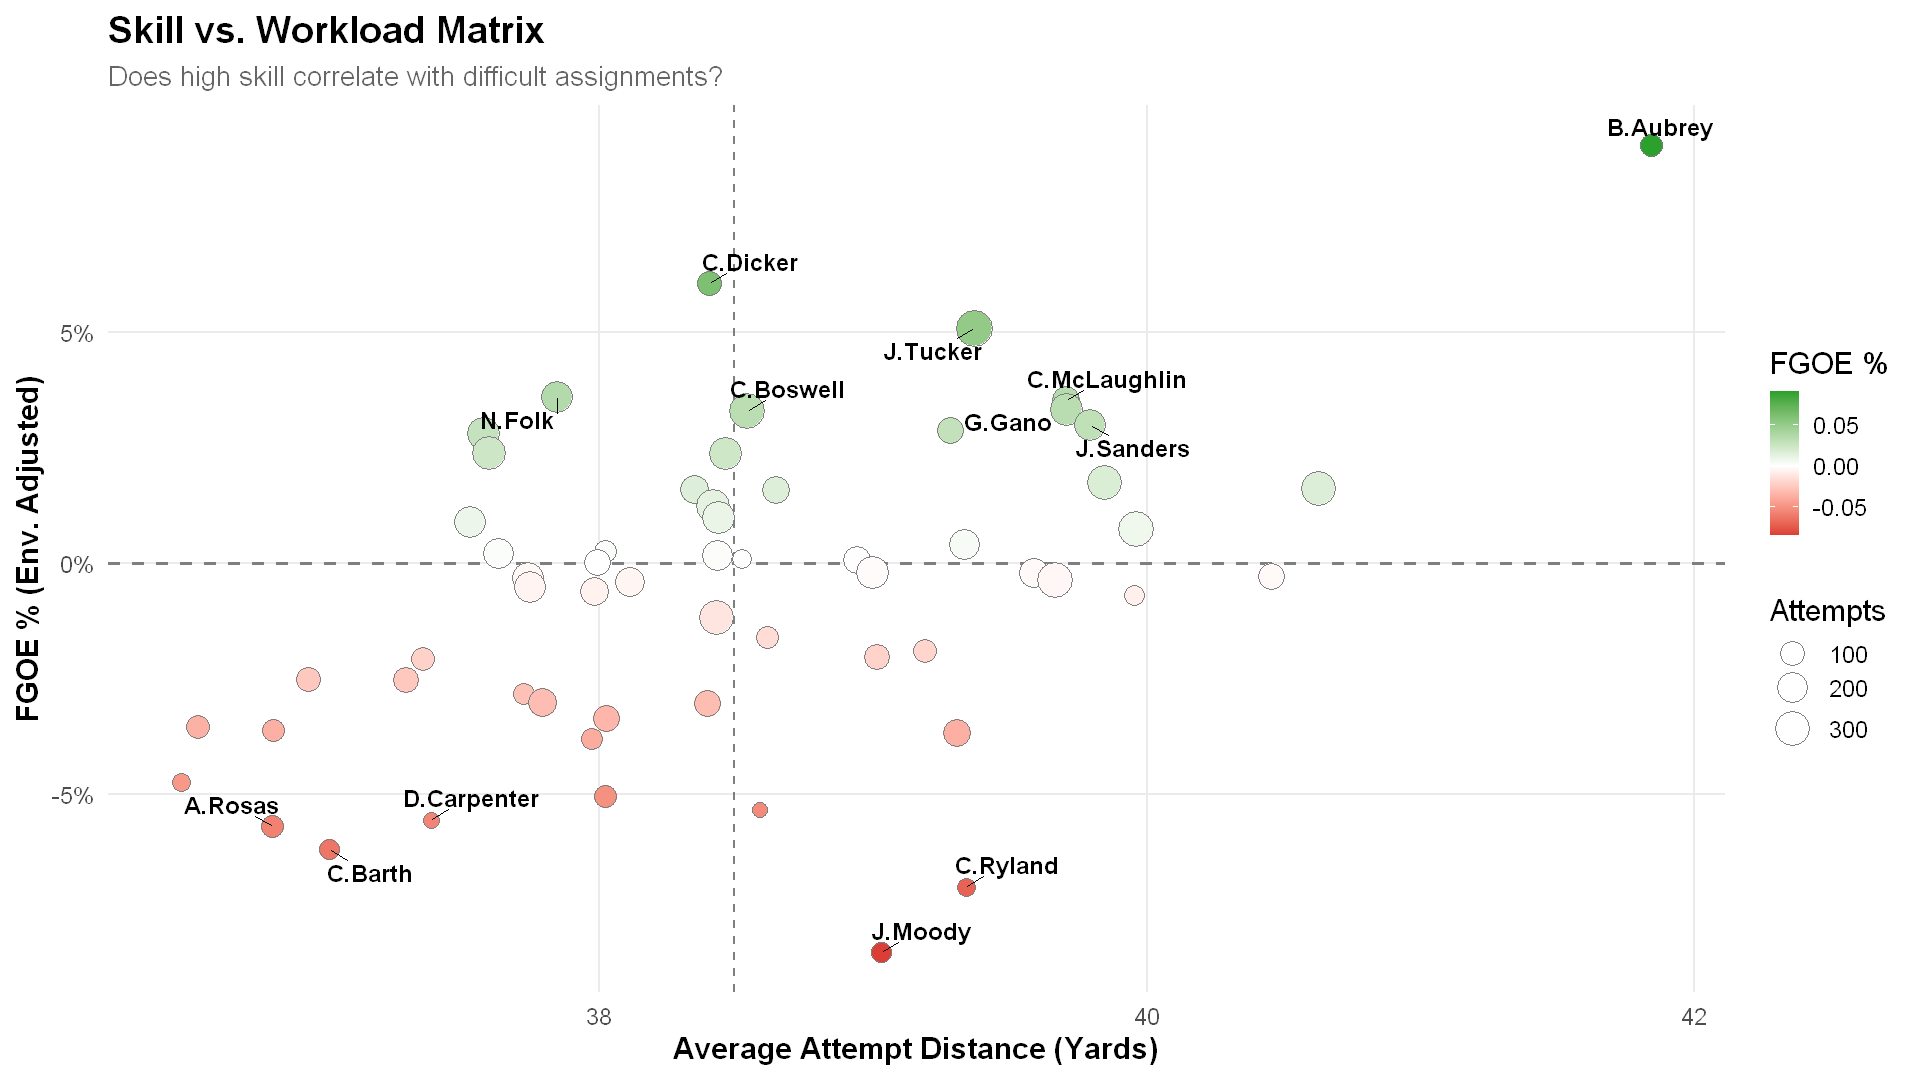

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


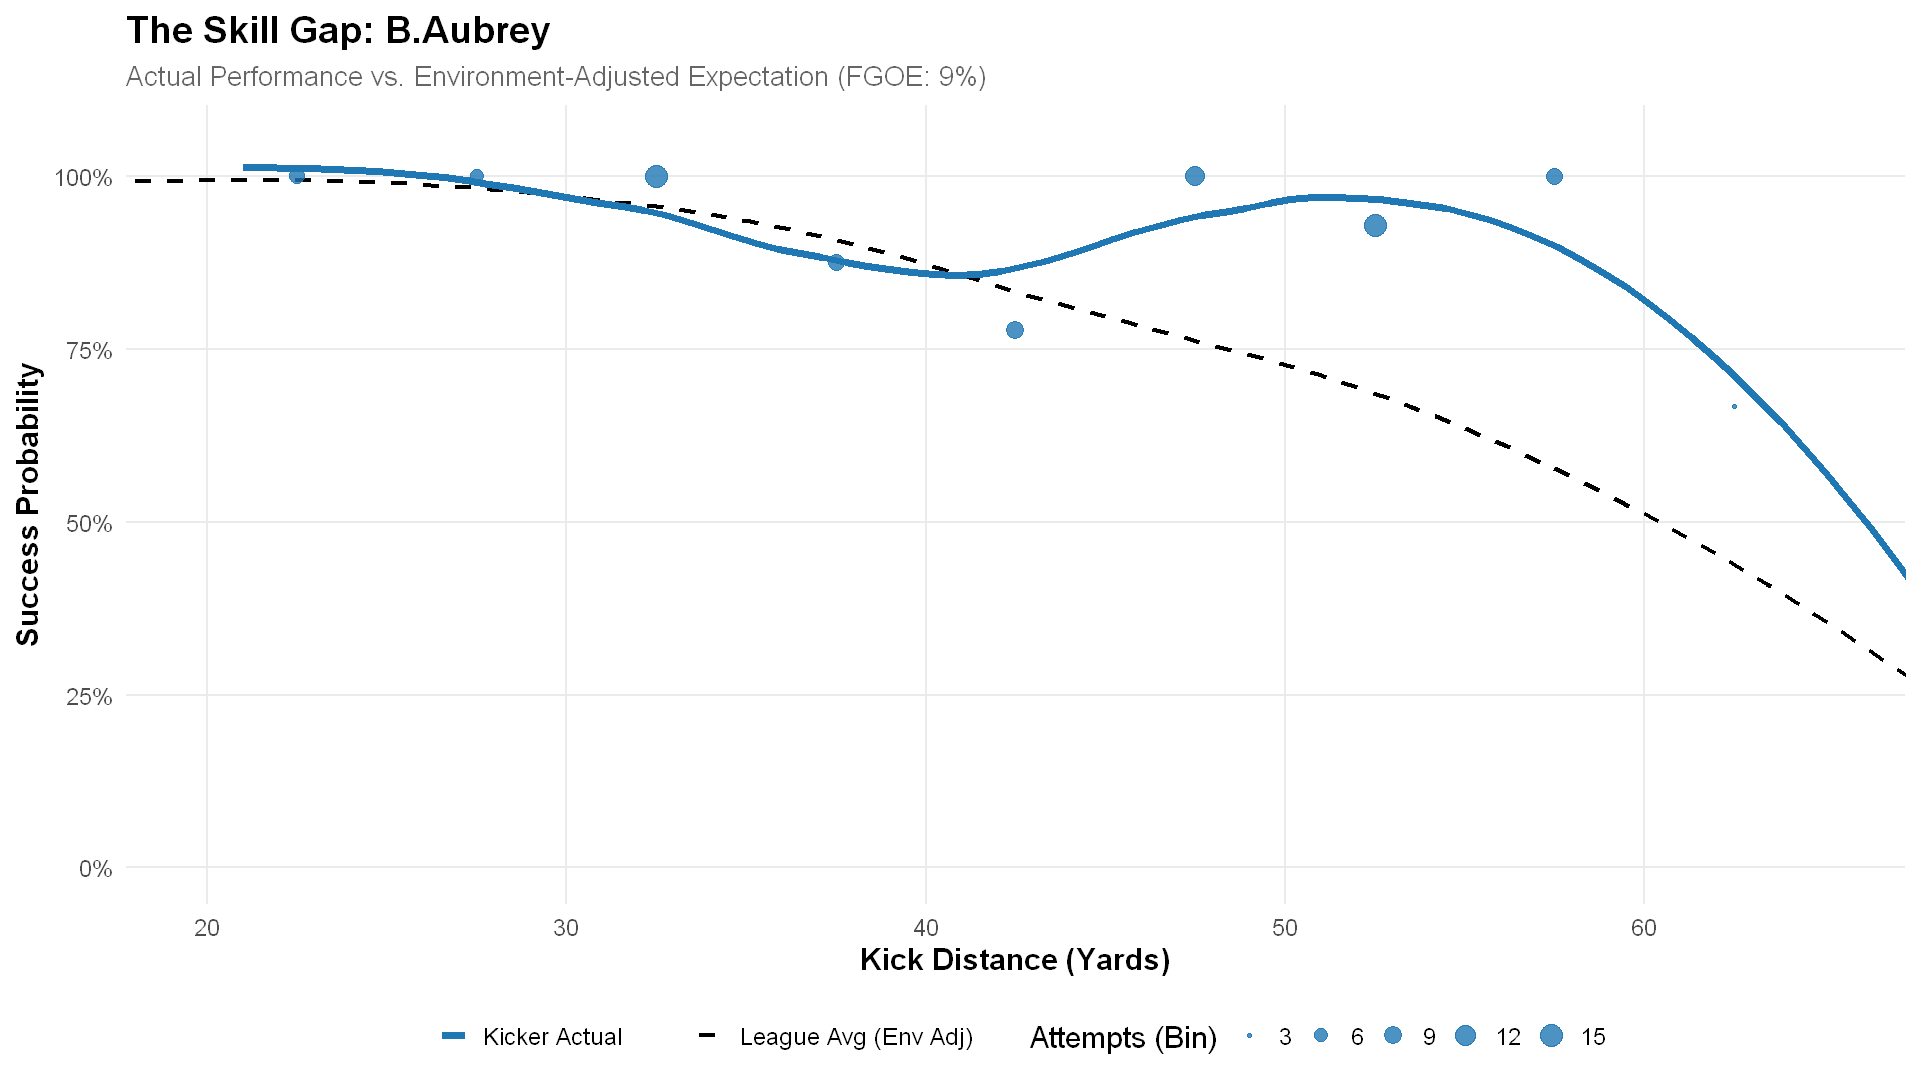

In [45]:
library(tidyverse)
library(ggrepel)

# ==============================================================================
# 3. Calculate Skill Metrics (Agnostic Basis)
# ==============================================================================

# Ensure Kicker Name column exists
if(!"kicker_player_name" %in% names(fg_full_pooled)) {
  fg_full_pooled$kicker_player_name <- fg_full_pooled$kicker_player_id
}

# Calculate FGOE (Field Goal Over Expectation)
kicker_skill_agnostic <- fg_full_pooled %>%
  dplyr::group_by(kicker_player_name) %>%
  dplyr::summarise(
    Seasons = n_distinct(season),
    Attempts = n(),
    Actual_Makes = sum(kick_made),
    
    # Expectation: M1 Agnostic (Env adjusted, Kicker neutral)
    # Note: Ensure 'p_m1_agnostic' is in your dataframe
    Exp_Makes_Agnostic = sum(p_m1_agnostic), 
    
    # The Metric: FGOE
    FGOE_Total = Actual_Makes - Exp_Makes_Agnostic,
    FGOE_Per_Kick = FGOE_Total / Attempts,
    
    # Context
    Avg_Distance = mean(kick_distance),
    Actual_Pct = mean(kick_made),
    
    .groups = "drop"
  ) %>%
  dplyr::filter(Attempts >= 50) %>%
  dplyr::arrange(desc(FGOE_Per_Kick))

# Print Top 10 Text Output
cat("\n--- Top 10 Kickers by True Skill (Environment Adjusted FGOE) ---\n")
print(head(kicker_skill_agnostic, 10))

# ==============================================================================
# 4. Visualizations (16:9 Format)
# ==============================================================================

# Setup Common Theme
slide_theme <- theme_minimal(base_size = 18) +
  theme(
    plot.title = element_text(face = "bold", size = 22),
    plot.subtitle = element_text(size = 16, color = "grey40"),
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold")
  )

# --- A. Leaderboard (Top 10 & Bottom 5) ---
top_kickers <- head(kicker_skill_agnostic, 10)
bottom_kickers <- tail(kicker_skill_agnostic, 5)
plot_leaderboard <- bind_rows(top_kickers, bottom_kickers) %>%
  mutate(
    # Green for Positive FGOE, Red for Negative
    Color = ifelse(FGOE_Per_Kick > 0, "#2ca02c", "#d62728"),
    # Create Label: "Name (+5.2%)"
    Label_Text = paste0(round(FGOE_Per_Kick*100, 1), "%")
  )

p_rank_ag <- ggplot(plot_leaderboard, aes(x = reorder(kicker_player_name, FGOE_Per_Kick), y = FGOE_Per_Kick, fill = Color)) +
  geom_bar(stat = "identity", alpha = 0.8, width = 0.7) +
  coord_flip() +
  
  # Add value labels at the end of bars
  geom_text(aes(label = Label_Text, y = FGOE_Per_Kick + (sign(FGOE_Per_Kick) * 0.005)), 
            hjust = ifelse(plot_leaderboard$FGOE_Per_Kick > 0, -0.2, 1.2), 
            size = 5, fontface = "bold") +
  
  scale_fill_identity() +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(min(plot_leaderboard$FGOE_Per_Kick)*1.2, max(plot_leaderboard$FGOE_Per_Kick)*1.2)) +
  
  labs(
    title = "True Kicker Skill: FGOE Leaderboard (Kicker Agnostic Model)",
    subtitle = "Field Goal Over Expectation (Adjusted for Stadium, Weather, Season)",
    x = "", y = "Performance vs. Environment Expectation"
  ) +
  slide_theme

# --- B. Scatter (Skill vs Difficulty) ---
p_scatter_ag <- ggplot(kicker_skill_agnostic, aes(x = Avg_Distance, y = FGOE_Per_Kick)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50", size = 1) +
  geom_vline(xintercept = mean(kicker_skill_agnostic$Avg_Distance), linetype = "dashed", color = "grey50") +
  
  # Points
  geom_point(aes(size = Attempts, fill = FGOE_Per_Kick), shape = 21, color='grey50', alpha = 1) +
  
  # Labels for Top/Bottom performers
  ggrepel::geom_text_repel(
    data = bind_rows(head(kicker_skill_agnostic, 8), tail(kicker_skill_agnostic, 5)), 
    aes(label = kicker_player_name), 
    size = 5, fontface = "bold", box.padding = 0.5
  ) +
  
  scale_fill_gradient2(low = "#d62728", mid = "white", high = "#2ca02c", midpoint = 0, name = "FGOE %") +
  scale_size_continuous(range = c(4, 10)) +
  scale_y_continuous(labels = scales::percent) +
  
  labs(
    title = "Skill vs. Workload Matrix",
    subtitle = "Does high skill correlate with difficult assignments?",
    x = "Average Attempt Distance (Yards)", y = "FGOE % (Env. Adjusted)"
  ) +
  slide_theme + theme(legend.position = "right")

# --- C. The GOAT Curve (Top Kicker vs Baseline) ---
# Identify Top Kicker
goat_id <- kicker_skill_agnostic$kicker_player_name[1] 

# Prepare Data
goat_data <- fg_full_pooled %>% 
  filter(kicker_player_name == goat_id) %>%
  mutate(bin = floor(kick_distance/5)*5) %>%
  group_by(bin) %>%
  summarise(n = n(), obs_rate = mean(kick_made), .groups = "drop") %>%
  filter(n >= 3) # Minimum sample size for points

# League Average Curve Data (Smooth)
league_curve_data <- fg_full_pooled %>%
  select(kick_distance, p_m1_agnostic)

p_curve_ag <- ggplot() +
  # 1. League Average Line (Smoothed Expectation)
  geom_smooth(data = league_curve_data, aes(x = kick_distance, y = p_m1_agnostic, linetype = "League Avg (Env Adj)"), 
              color = "black", size = 1.2, se = FALSE, method = "loess") +
  
  # 2. Kicker Actual Performance (Smoothed)
  geom_smooth(data = fg_full_pooled %>% filter(kicker_player_name == goat_id), 
              aes(x = kick_distance, y = kick_made, color = "Kicker Actual"), 
              method = "loess", se = FALSE, size = 2) +
  
  # 3. Kicker Actual Binned Points
  geom_point(data = goat_data, aes(x = bin + 2.5, y = obs_rate, size = n), color = "#1f77b4", alpha = 0.8) +
  
  # Formatting
  scale_color_manual(values = c("Kicker Actual" = "#1f77b4")) +
  scale_linetype_manual(values = c("League Avg (Env Adj)" = "dashed")) +
  
  coord_cartesian(ylim = c(0, 1.05), xlim = c(20, 65)) +
  scale_y_continuous(labels = scales::percent) +
  
  labs(
    title = paste0("The Skill Gap: ", goat_id),
    subtitle = paste0("Actual Performance vs. Environment-Adjusted Expectation (FGOE: ", 
                      round(kicker_skill_agnostic$FGOE_Per_Kick[1]*100, 1), "%)"),
    x = "Kick Distance (Yards)", y = "Success Probability",
    color = "", linetype = "", size = "Attempts (Bin)"
  ) +
  slide_theme

# ==============================================================================
# 5. Output / Save (16:9 Aspect Ratio)
# ==============================================================================

options(repr.plot.width = 16, repr.plot.height = 9)

print(p_rank_ag)
print(p_scatter_ag)
print(p_curve_ag)

if(exists("reports_dir")) {
  ggsave(file.path(reports_dir, "skill_leaderboard.png"), p_rank_ag, width = 16, height = 9)
  ggsave(file.path(reports_dir, "skill_vs_workload_scatter.png"), p_scatter_ag, width = 16, height = 9)
  ggsave(file.path(reports_dir, "skill_gap_curve.png"), p_curve_ag, width = 16, height = 9)
}